# RQ: Predict whether a reported crime results in an arrest, and examine how the domestic/non-domestic distinction affects model behavior and feature importance.

## Context
Crime in Chicago has been a persistent subject of public concern and academic inquiry. 
While much attention focuses on overall crime rates, less attention is paid to **how 
the circumstances of a crime, particularly whether it is domestic, shape the 
likelihood of an arrest**. This distinction matters sociologically because domestic 
and non-domestic crimes unfold in fundamentally different social contexts: one occurs 
within intimate relationships and private spaces, the other in public or semi-public 
settings involving strangers or acquaintances.

Using over 1.4 million crime incidents reported to the Chicago Police Department 
between 2018 and 2023, this project train machine learning models to predict arrest likelihood 
and use the models' behavior to examine whether the domestic/non-domestic distinction independently 
predicts arrest outcomes, and whether that relationship varies across time and space. 

## Part 1: Explainatory Data Analysis

### 1. Data Collection

The dataset is sourced from the **Chicago Data Portal** via the Socrata Open Data API (SODA). Data were accessed through year 2018–2023 and select the 14 columns relevant to our research question. 

In [15]:
import pandas as pd
import requests
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import io
import os
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

In [ ]:

url = "https://data.cityofchicago.org/resource/ijzp-q8t2.csv"

FILE_PATH = "data/chicago_crimes_2018_2023.csv"

if os.path.exists(FILE_PATH):
    print("skipping API call")
    df = pd.read_csv(FILE_PATH)
    print(f"  Loaded {len(df):,} rows from {FILE_PATH}")

else:
    print("File not found, pulling from API...")
    os.makedirs("data", exist_ok=True)  
    
    dfs = []
    limit = 500000
    offset = 0

    while True:
        params = {
            "$$app_token": "iAZp9mxjcw3dt8SUNugTPYJbS",
            "$limit": limit,
            "$offset": offset,
            "$where": "year >= 2018 AND year <= 2023",
            "$select": "date,primary_type,description,location_description,arrest,domestic,community_area,district,ward,fbi_code,iucr,latitude,longitude,year"
        }

        r = requests.get(url, params=params)
        print(f"Status code: {r.status_code}")
        if r.status_code != 200:
            print(f"Error response: {r.text[:500]}")
            break

        df_chunk = pd.read_csv(io.StringIO(r.text))
        if len(df_chunk) == 0:
            break

        dfs.append(df_chunk)
        offset += limit
        print(f"Pulled {offset} rows so far...")

    df = pd.concat(dfs, ignore_index=True)
    print(f"Total rows: {len(df):,}")
    df.to_csv(FILE_PATH, index=False)
    print(f" Saved to {FILE_PATH}")

df.to_csv("data/chicago_crimes_2018_2023.csv", index=False) 

skipping API call
  Loaded 1,456,462 rows from data/chicago_crimes_2018_2023.csv


### 2. What Does the Data Look Like?

Before any processing, it is important to inspect the raw data to understand its structure. 

Display the first few rows, last few rows, a random sample, column dtypes, and basic descriptive statistics for both numerical and categorical columns.

In [17]:
# Plot styling
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120

In [18]:
# LOAD DATA
df = pd.read_csv("data/chicago_crimes_2018_2023.csv")

In [19]:
# data overview
display(df.head())

display(df.tail())

display(df.sample(5, random_state=42))

display(df.dtypes.to_frame(name="dtype"))

display(df.describe())

display(df.describe(include="object"))


,date,primary_type,description,location_description,arrest,domestic,community_area,district,ward,fbi_code,iucr,latitude,longitude,year
0,2023-12-31T23:59:00.000,CRIMINAL DAMAGE,TO VEHICLE,STREET,False,False,8.0,18,27.0,14,1320,41.900698,-87.637330,2023
1,2023-12-31T23:51:00.000,ASSAULT,AGGRAVATED - OTHER DANGEROUS WEAPON,APARTMENT,False,True,69.0,6,8.0,04A,0530,41.754967,-87.602411,2023
2,2023-12-31T23:51:00.000,ASSAULT,AGGRAVATED POLICE OFFICER - HANDGUN,STREET,True,False,37.0,9,20.0,04A,0550,41.801584,-87.633177,2023
3,2023-12-31T23:50:00.000,BATTERY,DOMESTIC BATTERY SIMPLE,RESIDENCE,False,True,63.0,9,14.0,08B,0486,41.800201,-87.691535,2023
4,2023-12-31T23:50:00.000,BATTERY,"AGGRAVATED P.O. - HANDS, FISTS, FEET, NO / MIN...",STREET,False,False,25.0,25,37.0,08B,0454,41.906519,-87.758360,2023


,date,primary_type,description,location_description,arrest,domestic,community_area,district,ward,fbi_code,iucr,latitude,longitude,year
1456457,2018-01-01T00:00:00.000,THEFT,OVER $500,APARTMENT,False,False,30.0,10,22.0,06,0810,NaN,NaN,2018
1456458,2018-01-01T00:00:00.000,BURGLARY,UNLAWFUL ENTRY,OTHER,False,False,8.0,18,27.0,05,0620,41.909833,-87.637587,2018
1456459,2018-01-01T00:00:00.000,DECEPTIVE PRACTICE,FRAUD OR CONFIDENCE GAME,COMMERCIAL / BUSINESS OFFICE,False,False,8.0,18,42.0,11,1130,NaN,NaN,2018
1456460,2018-01-01T00:00:00.000,SEX OFFENSE,AGG CRIMINAL SEXUAL ABUSE,RESIDENCE,False,True,54.0,5,9.0,17,1562,41.653447,-87.608635,2018
1456461,2018-01-01T00:00:00.000,DECEPTIVE PRACTICE,CREDIT CARD FRAUD,OTHER (SPECIFY),False,False,20.0,25,26.0,11,1150,NaN,NaN,2018


,date,primary_type,description,location_description,arrest,domestic,community_area,district,ward,fbi_code,iucr,latitude,longitude,year
566102,2021-09-17T16:00:00.000,THEFT,PURSE-SNATCHING,SIDEWALK,False,False,8.0,18,2.0,06,0880,41.903892,-87.631858,2021
544895,2021-10-20T20:00:00.000,CRIMINAL DAMAGE,TO PROPERTY,APARTMENT,False,False,25.0,15,28.0,14,1310,41.881739,-87.751359,2021
819496,2020-07-04T23:00:00.000,ASSAULT,AGGRAVATED - HANDGUN,ALLEY,False,False,21.0,14,35.0,04A,051A,41.932031,-87.707778,2020
572290,2021-09-08T02:13:00.000,ASSAULT,AGGRAVATED - OTHER DANGEROUS WEAPON,GAS STATION,False,False,25.0,15,28.0,04A,0530,41.876581,-87.745138,2021
570065,2021-09-11T16:26:00.000,BATTERY,AGGRAVATED - OTHER DANGEROUS WEAPON,RESIDENCE,False,False,17.0,16,38.0,04B,0430,41.951674,-87.804800,2021


,dtype
date,str
primary_type,str
description,str
location_description,str
arrest,bool
domestic,bool
community_area,float64
district,int64
ward,float64
fbi_code,str


,community_area,district,ward,latitude,longitude,year
count,1.456331e+06,1.456462e+06,1.456410e+06,1.429660e+06,1.429660e+06,1.456462e+06
mean,3.666292e+01,1.124908e+01,2.324403e+01,4.184397e+01,-8.766954e+01,2.020467e+03
std,2.152741e+01,7.006961e+00,1.398417e+01,8.735725e-02,5.968063e-02,1.769503e+00
min,1.000000e+00,1.000000e+00,1.000000e+00,3.661945e+01,-9.168657e+01,2.018000e+03
25%,2.300000e+01,6.000000e+00,1.000000e+01,4.176823e+01,-8.771178e+01,2.019000e+03
50%,3.200000e+01,1.000000e+01,2.400000e+01,4.186198e+01,-8.766295e+01,2.020000e+03
75%,5.300000e+01,1.700000e+01,3.400000e+01,4.190676e+01,-8.762728e+01,2.022000e+03
max,7.700000e+01,3.100000e+01,5.000000e+01,4.202267e+01,-8.752453e+01,2.023000e+03


/var/folders/jl/s9dq32gs4w9c_2fvxv8nd9500000gn/T/ipykernel_6975/3291940378.py:12: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  display(df.describe(include="object"))


,date,primary_type,description,location_description,fbi_code,iucr
count,1456462,1456462,1456462,1448294,1456462,1456462
unique,702619,33,499,192,26,365
top,2021-01-01T00:00:00.000,THEFT,SIMPLE,STREET,06,0486
freq,181,322373,165101,363552,322376,126788


### 3. Data Size & Train / Validation / Test Split

**Data size:** ~1.4 million labeled incident records spanning 2018–2023.

**Split strategy:** We use a **70 / 15 / 15 stratified random split**:
- 70% training — used to fit the model
- 15% validation — used during hyperparameter tuning
- 15% test — held out entirely until final evaluation

I use `stratify=y` to preserve the 84/16 class ratio (not arrested / arrested) in every split. Without stratification, random chance could create splits with very different class proportions, which would distort both training and evaluation.

The project also uses a **random split** (rather than a temporal split) because the classification task is about predicting arrest likelihood from crime characteristics, not forecasting future trends. A temporal split would be more appropriate for a time series task.

In [20]:
# Count only labeled rows (non-null arrest)
labeled = df[df['arrest'].notna()].copy()

print(f'Total rows in dataset:          {len(df):,}')
print(f'Labeled rows (arrest not null): {len(labeled):,}')
print(f'Unlabeled or dropped:            {len(df) - len(labeled):,}')

# Temporarily encode arrest for stratified split check
labeled['arrest_temp'] = labeled['arrest'].astype(str).str.upper().map(
    {'TRUE': 1, 'FALSE': 0, '1': 1, '0': 0, '1.0': 1, '0.0': 0}
)
labeled = labeled[labeled['arrest_temp'].notna()]

train_df, temp_df = train_test_split(labeled, test_size=0.30, random_state=42, stratify=labeled['arrest_temp'])
val_df,   test_df = train_test_split(temp_df,  test_size=0.50, random_state=42, stratify=temp_df['arrest_temp'])

print(f'  Training set:   {len(train_df):,} rows ({len(train_df)/len(labeled)*100:.1f}%)')
print(f'  Validation set: {len(val_df):,}  rows ({len(val_df)/len(labeled)*100:.1f}%)')
print(f'  Test set:       {len(test_df):,}  rows ({len(test_df)/len(labeled)*100:.1f}%)')

# Work with labeled data going forward
df = labeled.drop(columns=['arrest_temp'])


Total rows in dataset:          1,456,462
Labeled rows (arrest not null): 1,456,462
Unlabeled or dropped:            0
  Training set:   1,019,523 rows (70.0%)
  Validation set: 218,469  rows (15.0%)
  Test set:       218,470  rows (15.0%)


### 4. Feature Space (X)

**13 features** grouped into three categories:

| Category | Features 
|---|---|
| **Temporal** | hour, day_of_week, month, season, is_weekend |
| **Spatial** | community_area, district, location_description |
| **Crime characteristics** | primary_type, domestic, fbi_code, iucr, year | 

**Feature types:**
- **Numerical (7):** hour, day_of_week, month, is_weekend, community_area, district, year
- **Categorical (6):** season, location_description, primary_type, domestic, fbi_code, iucr

With 13 features and ~1.4M samples, we have no dimensionality concerns (features << samples).

Temporal features (hour, day_of_week, month, season, is_weekend) are **engineered** from the raw `date` column, which is not used directly as a feature.

In [21]:
# Feature engineering from date
df['date']        = pd.to_datetime(df['date'])
df['hour']        = df['date'].dt.hour
df['day_of_week'] = df['date'].dt.dayofweek   # 0=Monday, 6=Sunday
df['month']       = df['date'].dt.month
df['is_weekend']  = df['day_of_week'].isin([5, 6]).astype(int)
df['season']      = df['month'].map({
    12: 'Winter', 1: 'Winter', 2: 'Winter',
    3:  'Spring', 4: 'Spring', 5: 'Spring',
    6:  'Summer', 7: 'Summer', 8: 'Summer',
    9:  'Fall',  10: 'Fall',  11: 'Fall'
})

FEATURES = {
    'hour'                    : 'numerical — continuous (0-23)',
    'day_of_week'             : 'numerical — ordinal (0=Mon, 6=Sun)',
    'month'                   : 'numerical — ordinal (1-12)',
    'season'                  : 'categorical — 4 classes',
    'is_weekend'              : 'numerical — binary (0/1)',
    'community_area'          : 'numerical — nominal (1-77)',
    'district'                : 'numerical — nominal',
    'location_description'    : 'categorical — high cardinality',
    'primary_type'            : 'categorical — 30 classes',
    'domestic'                : 'categorical — binary, KEY VARIABLE',
    'fbi_code'                : 'categorical — crime severity grouping',
    'iucr'                    : 'categorical — high cardinality',
    'year'                    : 'numerical — continuous (2018-2023)',
}

num_count = sum(1 for v in FEATURES.values() if 'numerical' in v)
cat_count = sum(1 for v in FEATURES.values() if 'categorical' in v)

print(f'Total features: {len(FEATURES)}')
print(f'  Numerical:   {num_count}')
print(f'  Categorical: {cat_count}')
print(f'\nFeature breakdown:')
for feat, desc in FEATURES.items():
    print(f'  {feat:<30} {desc}')
print(f'\n #features (13) << #samples ({len(df):,})')



Total features: 13
  Numerical:   7
  Categorical: 6

Feature breakdown:
  hour                           numerical — continuous (0-23)
  day_of_week                    numerical — ordinal (0=Mon, 6=Sun)
  month                          numerical — ordinal (1-12)
  season                         categorical — 4 classes
  is_weekend                     numerical — binary (0/1)
  community_area                 numerical — nominal (1-77)
  district                       numerical — nominal
  location_description           categorical — high cardinality
  primary_type                   categorical — 30 classes
  domestic                       categorical — binary, KEY VARIABLE
  fbi_code                       categorical — crime severity grouping
  iucr                           categorical — high cardinality
  year                           numerical — continuous (2018-2023)

 #features (13) << #samples (1,456,462)


### 5. Data Preprocessing

1. **Missing value analysis** — identify which columns have nulls and how many
2. **Drop rows with missing key features** — we can afford this given our large dataset size
3. **Data type corrections** — `arrest` and `domestic` come in as mixed strings/bools; we standardize to binary integers
4. **Outlier detection** — validate that `hour` (0–23) and `community_area` (1–77) have no invalid values
5. **Cardinality reduction** — `location_description` and `iucr` have hundreds of unique values; we keep the top 50 and group the rest as 'OTHER' to prevent sparse, uninformative encodings
6. **Label encoding** — convert remaining categorical columns to integers for model compatibility

> **Note on encoding choice:** I use Label Encoding here rather than One-Hot Encoding because our tree-based model (Random Forest) handles ordinal integers natively. For the linear model (Logistic Regression), I will apply One-Hot Encoding in the modeling notebook to avoid implying false ordinal relationships.

In [22]:
# Missing values
missing     = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df  = pd.DataFrame({'missing_count': missing, 'missing_%': missing_pct})
display(missing_df[missing_df['missing_count'] > 0].sort_values('missing_%', ascending=False))

# Drop rows missing key features
key_cols = ['arrest', 'community_area', 'district', 'location_description',
            'primary_type', 'domestic', 'fbi_code', 'iucr']
before = len(df)
df.dropna(subset=key_cols, inplace=True)
after  = len(df)

# Data type corrections 
for col in ['arrest', 'domestic']:
    df[col] = df[col].astype(str).str.strip().str.upper()
    df[col] = df[col].map({'TRUE': 1, 'FALSE': 0, '1': 1, '0': 0, '1.0': 1, '0.0': 0})
    df[col] = df[col].astype(int)

df['community_area'] = df['community_area'].astype(int)
df['district']       = df['district'].astype(int)

# Outlier detection
df = df[df['hour'].between(0, 23)]
df = df[df['community_area'].between(1, 77)]

# Cardinality reduction 
for col in ['location_description', 'iucr']:
    original_n = df[col].nunique()
    top50 = df[col].value_counts().nlargest(50).index
    df[col] = df[col].where(df[col].isin(top50), other='OTHER')

# Label encoding
le = LabelEncoder()
for col in ['season', 'location_description', 'primary_type', 'fbi_code', 'iucr']:
    df[col + '_encoded'] = le.fit_transform(df[col].astype(str))

,missing_count,missing_%
latitude,26802,1.84
longitude,26802,1.84
location_description,8168,0.56
community_area,131,0.01
ward,52,0.00


### 6. Target Variable (Y) Distribution

The target variable is `arrest` (binary: 1 = arrested, 0 = not arrested).

This section will visualize three things:
1. Overall class distribution
2. Arrest rate broken down by domestic vs. non-domestic crimes — our key sociological comparison
3. Arrest rate trend by year to check whether policing patterns have shifted over time

Given the imbalance dataset, will use `class_weight='balanced'` in all models and report **weighted F1-score** as the primary metric rather than accuracy.

  Not Arrested (0): 1,216,709 (84.0%)
  Arrested     (1): 231,454 (16.0%)

  This shows that imbalance present, will use class_weight='balanced' in models and evaluate using F1-score (weighted)


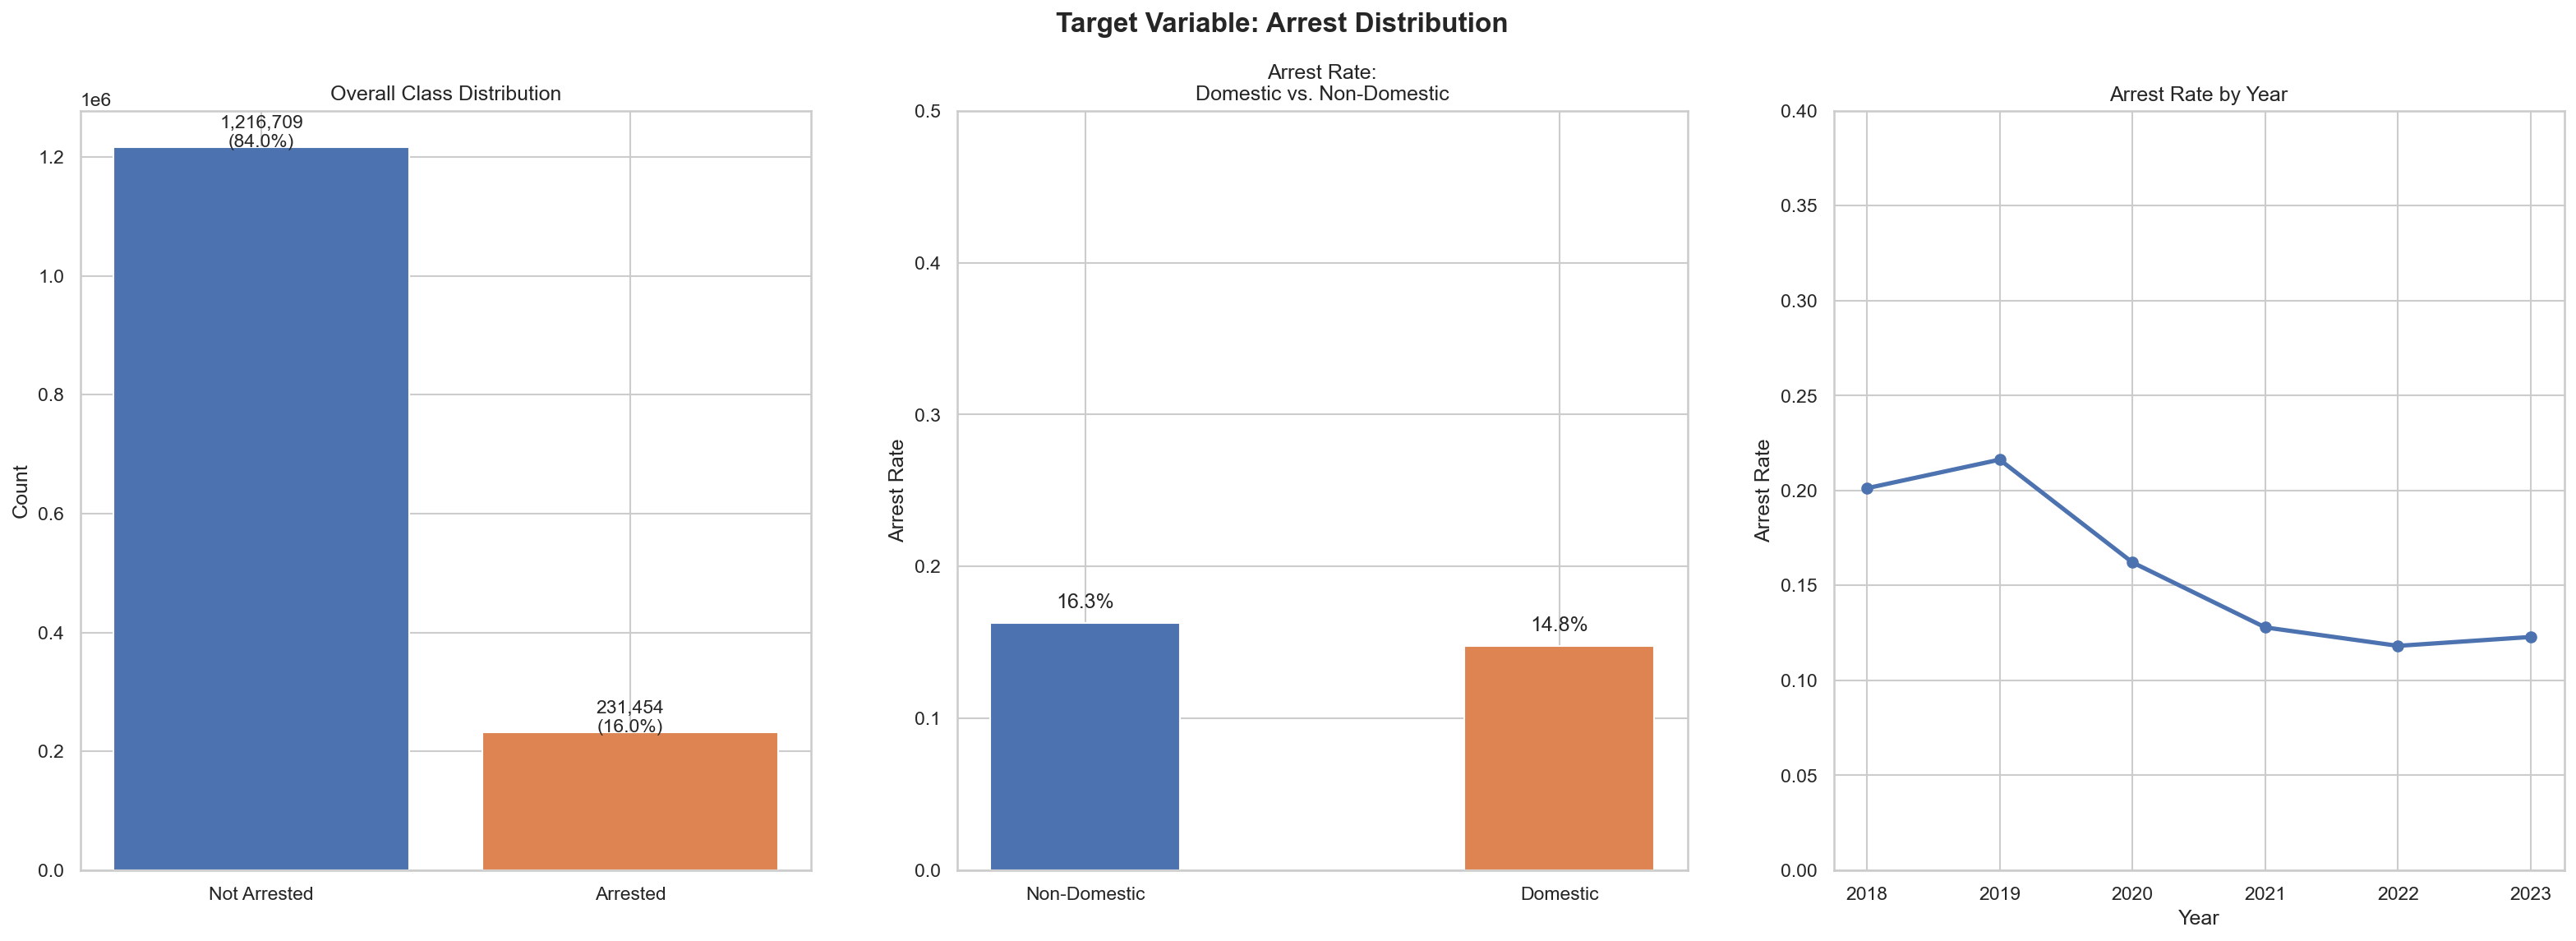

In [23]:
df['arrest'] = df['arrest'].astype(str).str.strip().str.upper()
df['arrest'] = df['arrest'].map({'TRUE': 1, 'FALSE': 0, '1': 1, '0': 0, '1.0': 1, '0.0': 0})
df = df[df['arrest'].notna()]
df['arrest'] = df['arrest'].astype(int)

arrest_counts = df['arrest'].value_counts().sort_index()
arrest_pct    = df['arrest'].value_counts(normalize=True).sort_index() * 100

print(f"  Not Arrested (0): {arrest_counts.iloc[0]:,} ({arrest_pct.iloc[0]:.1f}%)")
print(f"  Arrested     (1): {arrest_counts.iloc[1]:,} ({arrest_pct.iloc[1]:.1f}%)")
print(f"\n  This shows that imbalance present, will use class_weight='balanced' in models and evaluate using F1-score (weighted)")

df['domestic'] = df['domestic'].astype(str).str.strip().str.upper()
df['domestic'] = df['domestic'].map({'TRUE': 1, 'FALSE': 0, '1': 1, '0': 0, '1.0': 1, '0.0': 0})
df['domestic'] = df['domestic'].astype(int)

plt.rcParams["figure.dpi"] = 150
plt.rcParams["font.size"] = 12

fig, axes = plt.subplots(1, 3, figsize=(26, 8))  # wider
fig.suptitle("Target Variable: Arrest Distribution", fontsize=16, fontweight='bold')

# Chart 1 
axes[0].bar(['Not Arrested', 'Arrested'],
            [arrest_counts.iloc[0], arrest_counts.iloc[1]],
            color=['#4C72B0', '#DD8452'], edgecolor='white')
axes[0].set_title("Overall Class Distribution")
axes[0].set_ylabel("Count")
for i, v in enumerate([arrest_counts.iloc[0], arrest_counts.iloc[1]]):
    axes[0].text(i, v + 500, f"{v:,}\n({[arrest_pct.iloc[0], arrest_pct.iloc[1]][i]:.1f}%)",
                 ha='center', fontsize=11)

# Chart 2 explicitly sort by domestic value so order is consistent
arrest_by_domestic = df.groupby('domestic')['arrest'].mean().reset_index()
arrest_by_domestic = arrest_by_domestic.sort_values('domestic')  # ensure 0 first, 1 second
arrest_by_domestic['domestic_label'] = arrest_by_domestic['domestic'].map({0: 'Non-Domestic', 1: 'Domestic'})

axes[1].bar(arrest_by_domestic['domestic_label'], arrest_by_domestic['arrest'],
            color=['#4C72B0', '#DD8452'], edgecolor='white', width=0.4)
axes[1].set_title("Arrest Rate:\nDomestic vs. Non-Domestic")
axes[1].set_ylabel("Arrest Rate")
axes[1].set_ylim(0, 0.5)
for i, (_, row) in enumerate(arrest_by_domestic.iterrows()):
    axes[1].text(i, row['arrest'] + 0.01, f"{row['arrest']:.1%}", ha='center', fontsize=12)

# Chart 3
arrest_by_year = df.groupby('year')['arrest'].mean()
axes[2].plot(arrest_by_year.index, arrest_by_year.values, marker='o', color='#4C72B0', linewidth=2.5)
axes[2].set_title("Arrest Rate by Year")
axes[2].set_ylabel("Arrest Rate")
axes[2].set_xlabel("Year")
axes[2].set_ylim(0, 0.4)

# plt.tight_layout(rect=[0, 0, 1, 0.95])  
plt.show()


### 7. Domestic vs. Non-Domestic Crime Patterns

This section addresses the **research question** through exploratory analysis. According to **Routine Activity Theory**, crime patterns should reflect when and where motivated offenders and suitable targets converge without capable guardians.

For domestic crimes specifically, this predicts:
- **Evening/night peaks** — people are home after work
- **Weekend concentration** — more time spent at home together
- **Residence as primary location** — as opposed to streets or businesses
- **Different crime type profile** — battery and assault dominate rather than theft

If the data supports these patterns, it validates using `domestic` as a theoretically meaningful feature in the model.

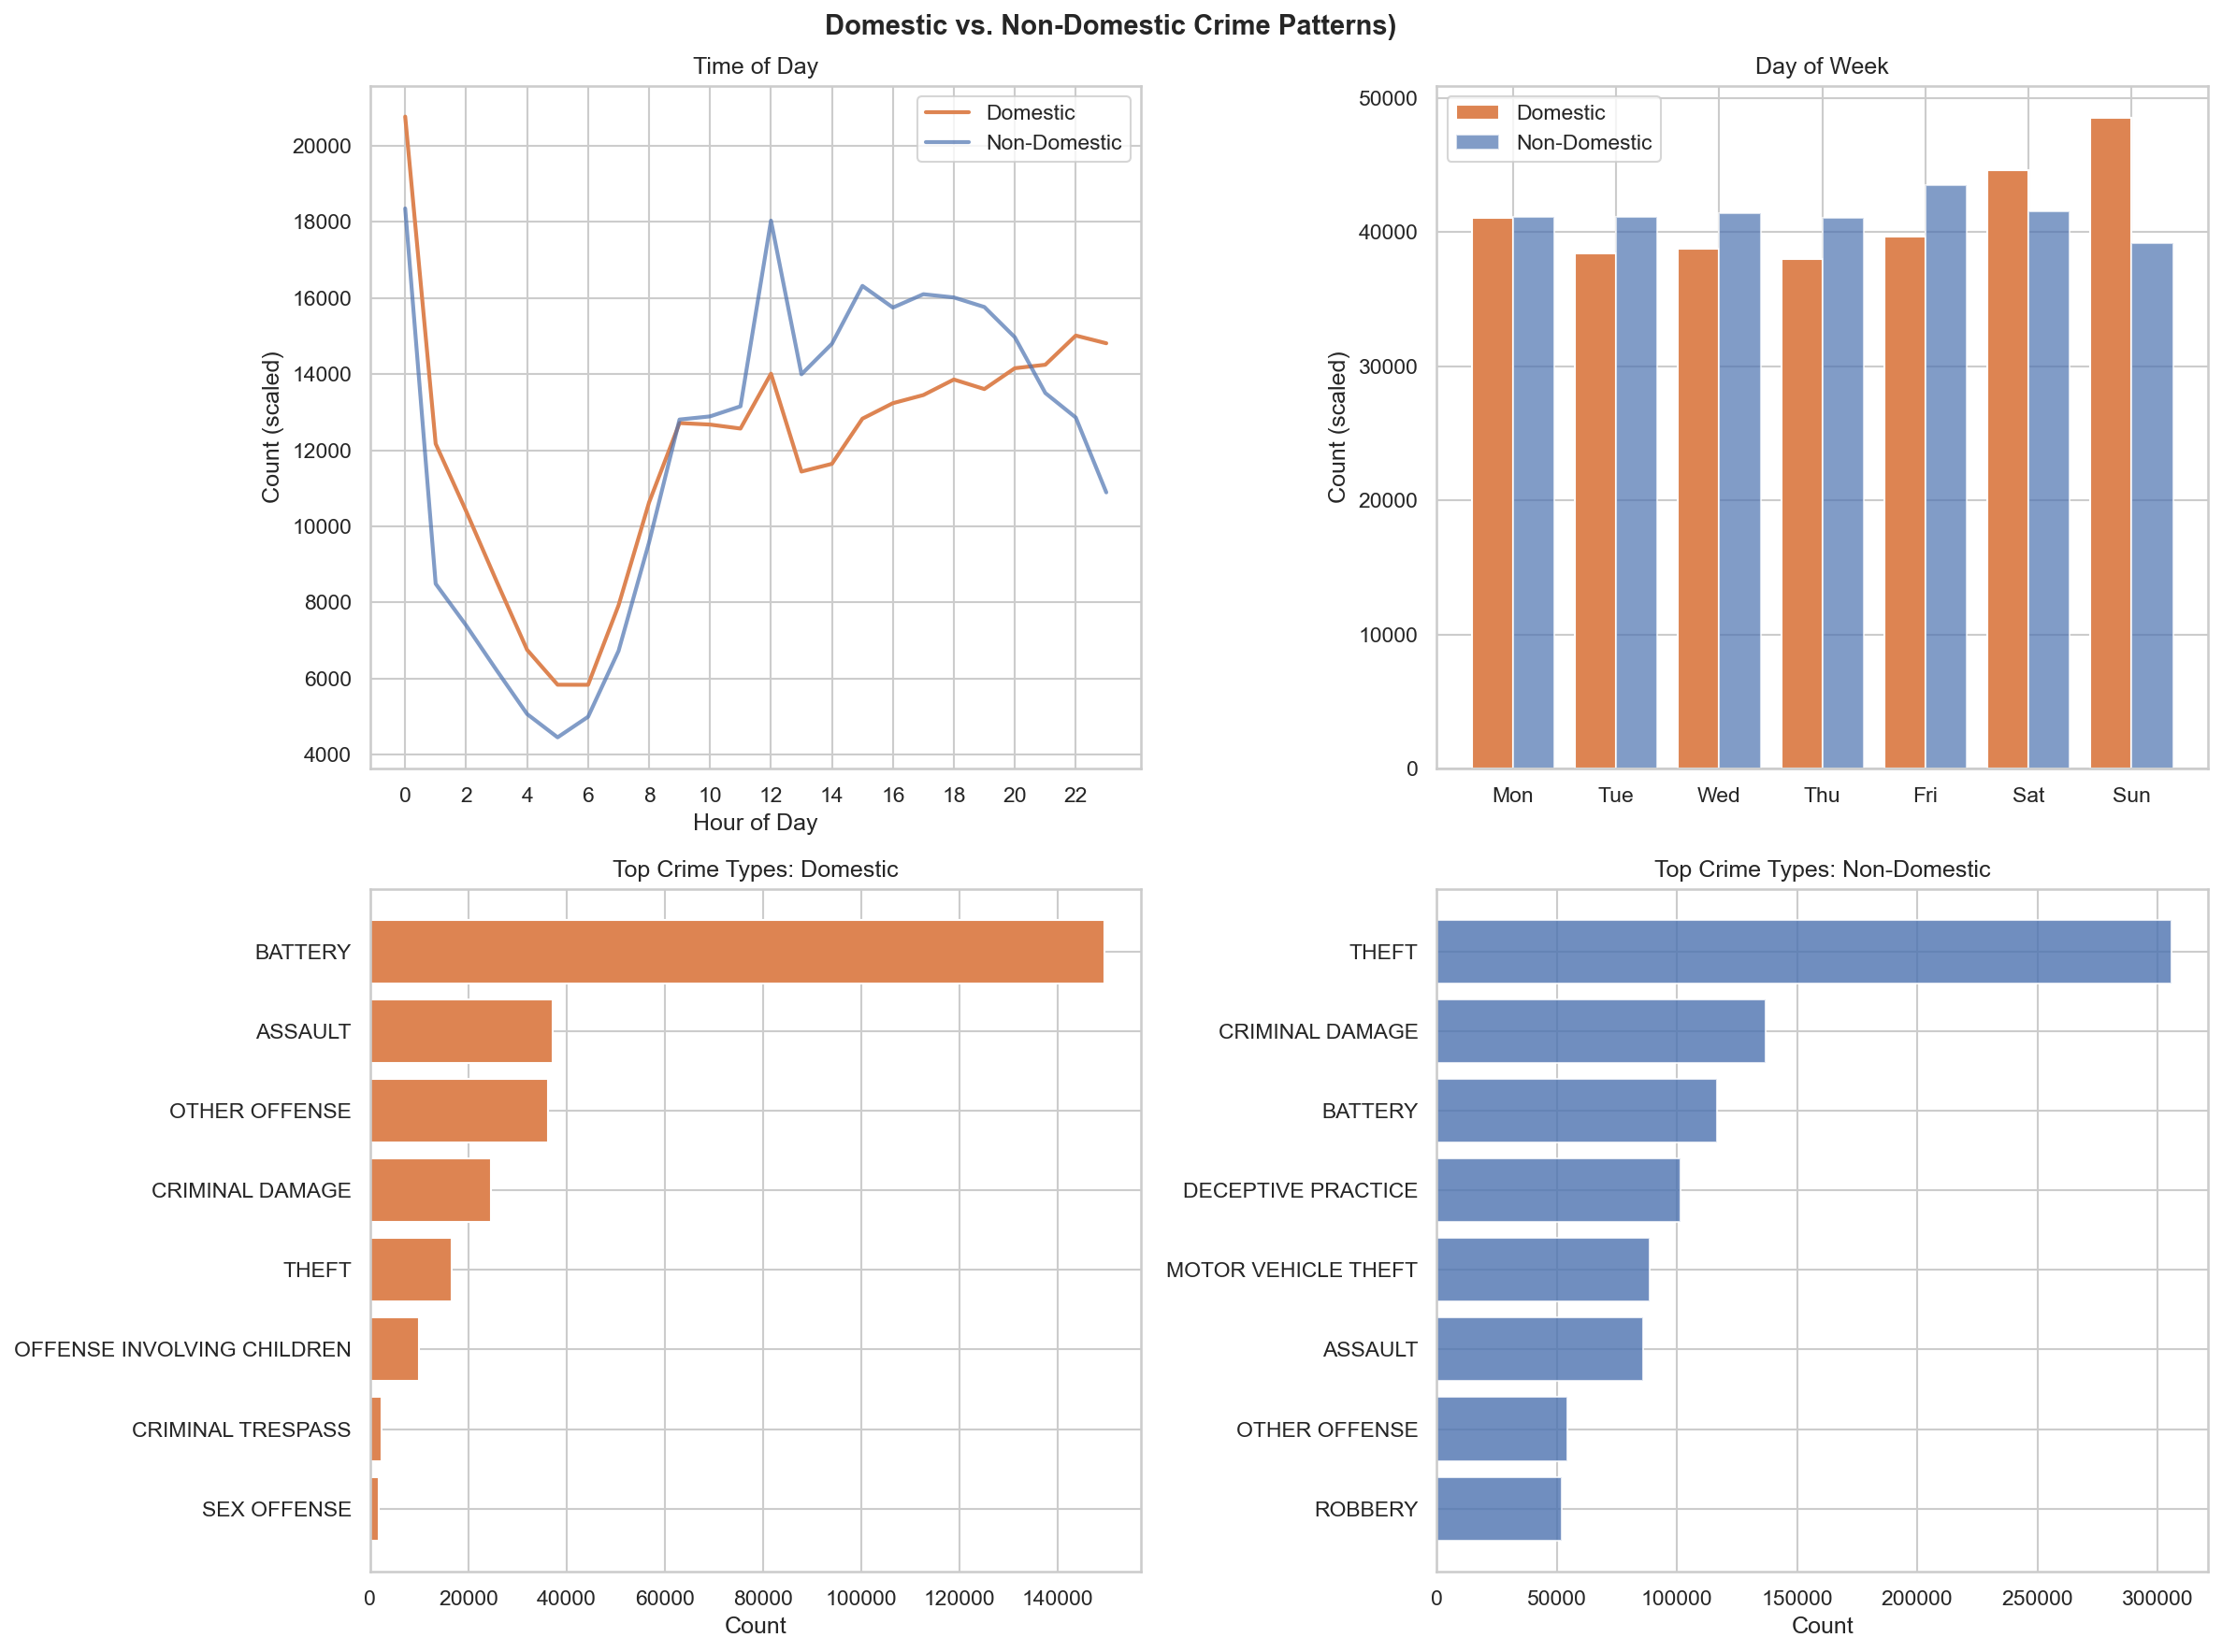

In [24]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle("Domestic vs. Non-Domestic Crime Patterns)",
             fontsize=14, fontweight='bold')

dom    = df[df['domestic'] == 1]
nondom = df[df['domestic'] == 0]

# --- 6a. Time of day ---
ax = axes[0, 0]
dom_hour    = dom['hour'].value_counts().sort_index()
nondom_hour = nondom['hour'].value_counts(normalize=True).sort_index() * len(dom)
ax.plot(dom_hour.index,    dom_hour.values,    label='Domestic',     color='#DD8452', linewidth=2)
ax.plot(nondom_hour.index, nondom_hour.values, label='Non-Domestic', color='#4C72B0', linewidth=2, alpha=0.7)
ax.set_title("Time of Day")
ax.set_xlabel("Hour of Day")
ax.set_ylabel("Count (scaled)")
ax.legend()
ax.set_xticks(range(0, 24, 2))

# --- 6b. Day of week ---
ax = axes[0, 1]
days = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
dom_day    = dom['day_of_week'].value_counts().sort_index()
nondom_day = nondom['day_of_week'].value_counts(normalize=True).sort_index() * len(dom)
x = np.arange(7)
ax.bar(x - 0.2, dom_day.values,    width=0.4, label='Domestic',     color='#DD8452')
ax.bar(x + 0.2, nondom_day.values, width=0.4, label='Non-Domestic', color='#4C72B0', alpha=0.7)
ax.set_title("Day of Week")
ax.set_xticks(x)
ax.set_xticklabels(days)
ax.set_ylabel("Count (scaled)")
ax.legend()

# --- 6c. Top crime types (domestic) ---
ax = axes[1, 0]
top_types_dom = dom['primary_type'].value_counts().nlargest(8)
ax.barh(top_types_dom.index[::-1], top_types_dom.values[::-1], color='#DD8452')
ax.set_title("Top Crime Types: Domestic")
ax.set_xlabel("Count")

# --- 6d. Top crime types (non-domestic) ---
ax = axes[1, 1]
top_types_nondom = nondom['primary_type'].value_counts().nlargest(8)
ax.barh(top_types_nondom.index[::-1], top_types_nondom.values[::-1], color='#4C72B0', alpha=0.8)
ax.set_title("Top Crime Types: Non-Domestic")
ax.set_xlabel("Count")

plt.tight_layout()

### 8. Spatial Distribution

Chicago's 77 community areas vary dramatically in socioeconomic conditions, racial composition, and policing intensity. This section examines whether domestic crime concentrates in specific community areas and whether arrest rates for domestic crimes vary geographically.

1. Which community areas have the highest **proportion** of crimes that are domestic?
2. Within domestic crimes, which community areas have the highest arrest rates?


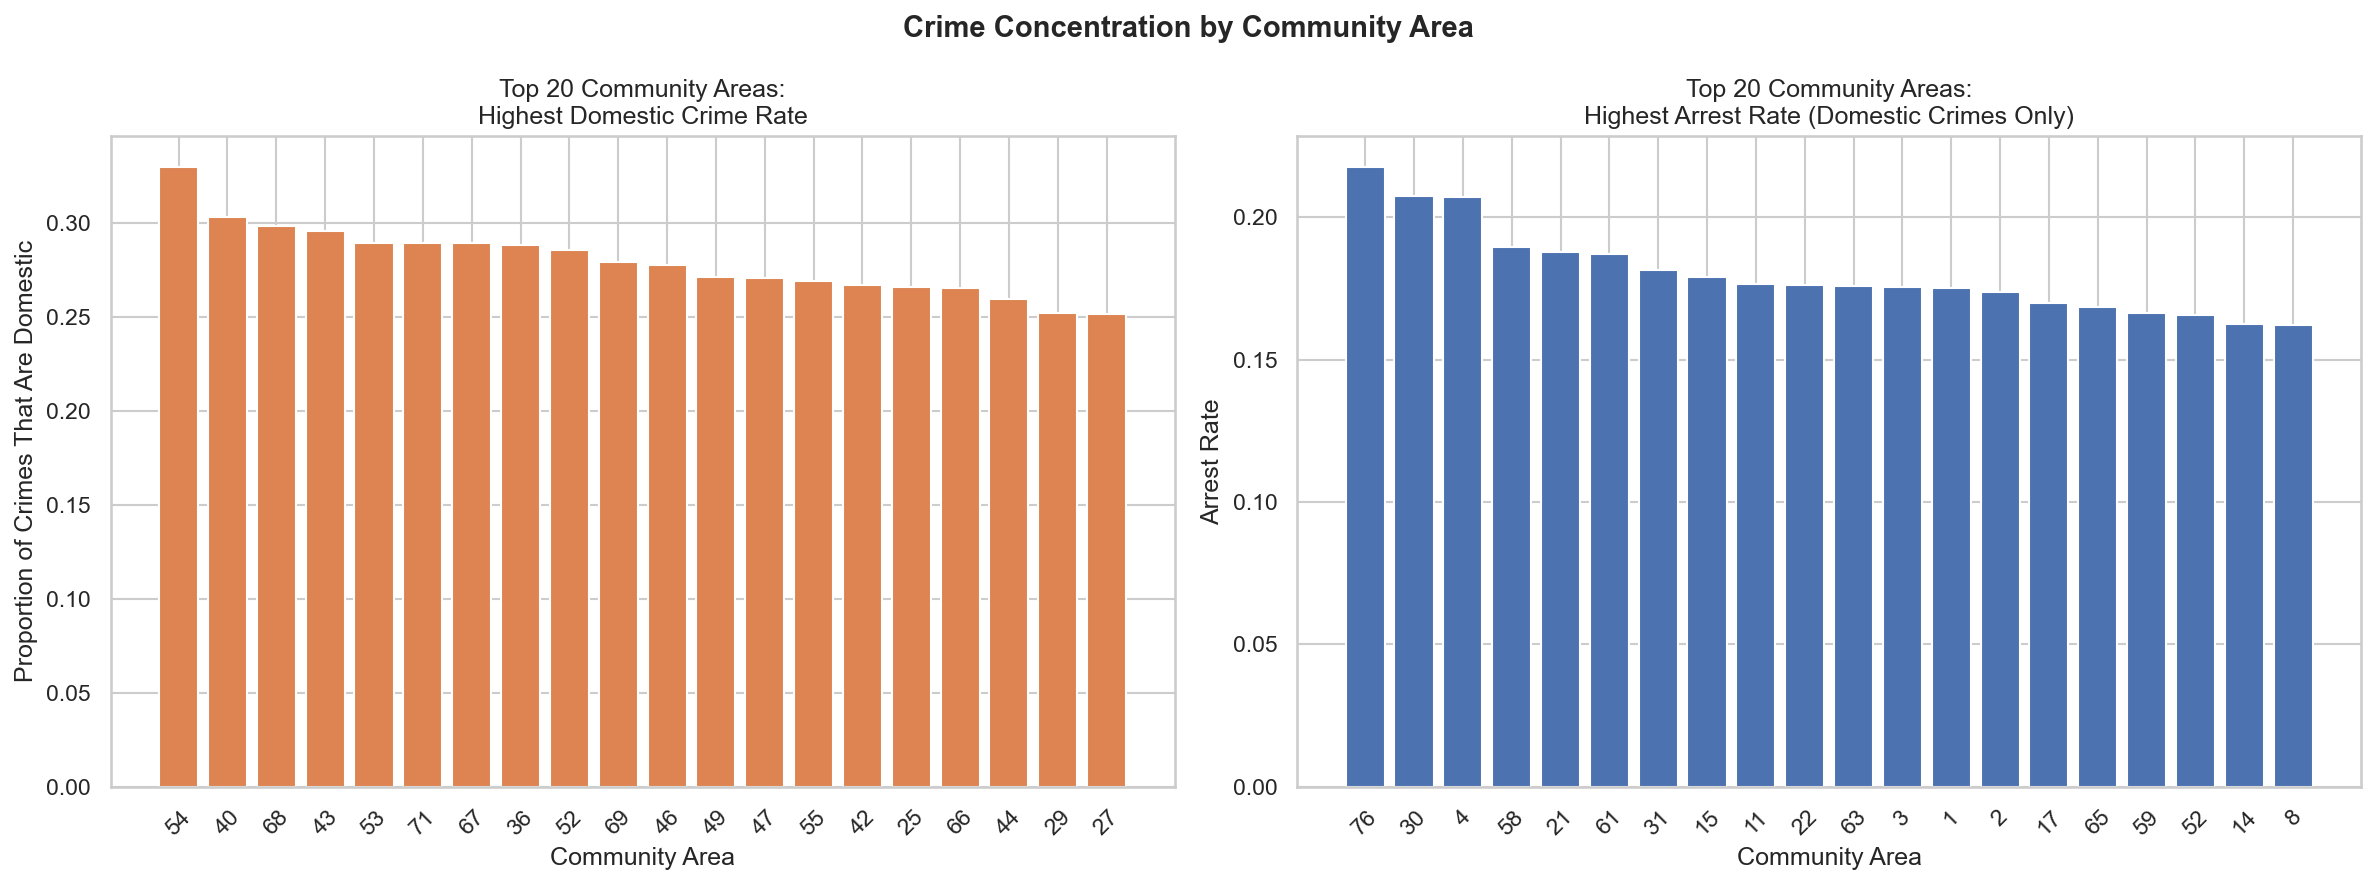

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Crime Concentration by Community Area", fontsize=14, fontweight='bold')

# Domestic crime rate per community area
dom_rate = df.groupby('community_area')['domestic'].mean().sort_values(ascending=False)
axes[0].bar(dom_rate.head(20).index.astype(str), dom_rate.head(20).values, color='#DD8452')
axes[0].set_title("Top 20 Community Areas:\nHighest Domestic Crime Rate")
axes[0].set_xlabel("Community Area")
axes[0].set_ylabel("Proportion of Crimes That Are Domestic")
axes[0].tick_params(axis='x', rotation=45)

# Arrest rate per community area (for domestic crimes only)
arrest_rate_dom = dom.groupby('community_area')['arrest'].mean().sort_values(ascending=False)
axes[1].bar(arrest_rate_dom.head(20).index.astype(str), arrest_rate_dom.head(20).values, color='#4C72B0')
axes[1].set_title("Top 20 Community Areas:\nHighest Arrest Rate (Domestic Crimes Only)")
axes[1].set_xlabel("Community Area")
axes[1].set_ylabel("Arrest Rate")
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

### 9. Feature Correlations

To examine pairwise correlations between all numerical features and the target variable (`arrest`),  
- Identify which features are most linearly associated with arrest likelihood
- Detect **multicollinearity** (high correlation between two features) — if two features are highly correlated, one may be redundant
- Validate that `domestic` has a meaningful relationship with the target

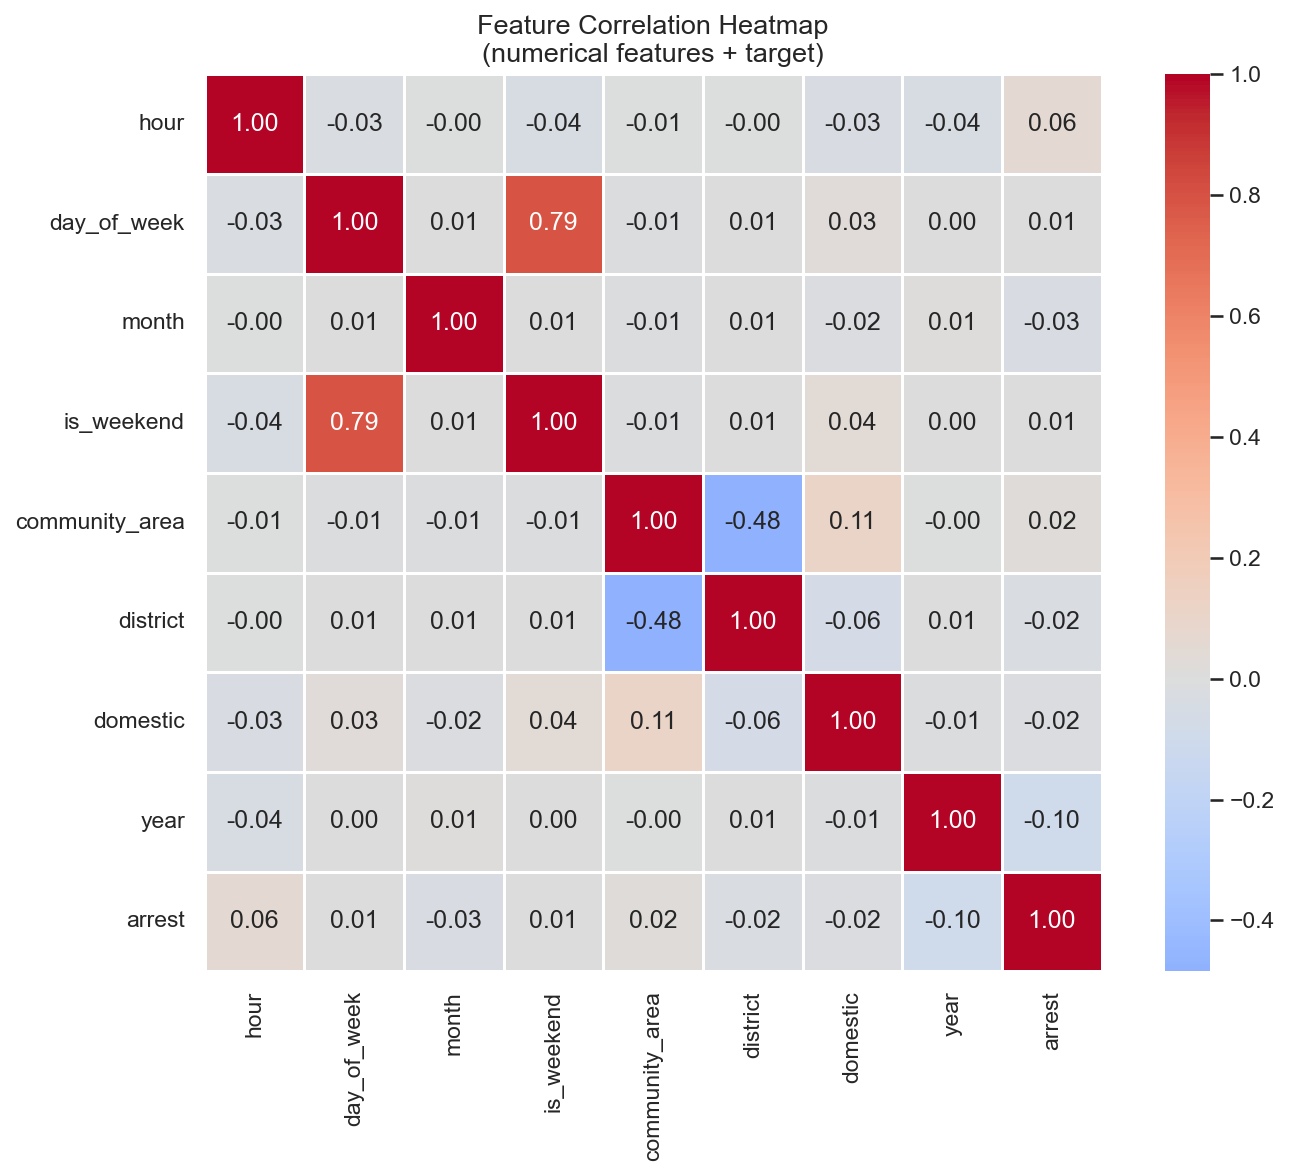

In [26]:
num_cols = ['hour', 'day_of_week', 'month', 'is_weekend',
            'community_area', 'district', 'domestic', 'year', 'arrest']
corr = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            square=True, linewidths=0.5, ax=ax)
ax.set_title("Feature Correlation Heatmap\n(numerical features + target)", fontsize=13)
plt.tight_layout()
plt.show()


### 10. Finalize

Finalze the feature matrix and target vector, perform the train/val/test split on the fully preprocessed data.

**Final feature set (13 features):**
- Temporal: `hour`, `day_of_week`, `month`, `season_encoded`, `is_weekend`
- Spatial: `community_area`, `district`, `location_description_encoded`
- Crime: `primary_type_encoded`, `domestic`, `fbi_code_encoded`, `iucr_encoded`, `year`

**Target:** `arrest` (binary: 0 = not arrested, 1 = arrested)

In [27]:
FEATURE_COLS = [
    'hour', 'day_of_week', 'month', 'season_encoded', 'is_weekend',
    'community_area', 'district', 'location_description_encoded',
    'primary_type_encoded', 'domestic', 'fbi_code_encoded',
    'iucr_encoded', 'year'
]
TARGET_COL = 'arrest'

# Check which cols are missing
missing_cols = [c for c in FEATURE_COLS if c not in df.columns]
if missing_cols:
    print(f"\n  Still missing: {missing_cols}")
else:
    print(f"\n  All {len(FEATURE_COLS)} feature columns present")

print(f"\nFinal feature columns ({len(FEATURE_COLS)}):")
for f in FEATURE_COLS:
    print(f"  {f}")
print(f"\nTarget: {TARGET_COL}")
print(f"Final dataset size: {len(df):,} rows")
print(f"\nClass distribution in final dataset:")
print(df[TARGET_COL].value_counts().to_string())

# Save preprocessed dataset
X = df[FEATURE_COLS]
y = df[TARGET_COL]

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, random_state=42, stratify=y)
X_val, X_test, y_val, y_test     = train_test_split(X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp)

print(f"\nFinal splits:")
print(f"  X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"  X_val:   {X_val.shape},   y_val:   {y_val.shape}")
print(f"  X_test:  {X_test.shape},  y_test:  {y_test.shape}")



  All 13 feature columns present

Final feature columns (13):
  hour
  day_of_week
  month
  season_encoded
  is_weekend
  community_area
  district
  location_description_encoded
  primary_type_encoded
  domestic
  fbi_code_encoded
  iucr_encoded
  year

Target: arrest
Final dataset size: 1,448,163 rows

Class distribution in final dataset:
arrest
0    1216709
1     231454

Final splits:
  X_train: (1013714, 13), y_train: (1013714,)
  X_val:   (217224, 13),   y_val:   (217224,)
  X_test:  (217225, 13),  y_test:  (217225,)


## Part 2: Model Exploration

**Task:** Binary Classification, predict whether a reported crime results in an arrest (`arrest` = 1 or 0)

#### Models Used

| Model | Type | Justification |
|---|---|---|
| Logistic Regression | Supervised — Linear | Interpretable coefficients; good baseline for binary classification; directly reveals feature weights |
| Random Forest | Supervised — Tree-based | Handles non-linear interactions; robust to outliers; feature importance scores align with sociological interpretation |
| K-Means Clustering | Unsupervised | Groups community areas into typologies based on crime profile — supports the spatial dimension of our RQ |

**Why these models fit the task:**
- With ~1.4M samples and 13 features, Logistic Regression and Random Forest are appropriately scaled. A neural network would be over-complex for this tabular task and harder to interpret sociologically.
- Both supervised models handle class imbalance via `class_weight='balanced'`
- K-Means on community-area aggregates provides an unsupervised lens on neighborhood typologies, complementing the supervised task


In [28]:
import warnings
warnings.filterwarnings('ignore')

# Supervised models
from sklearn.linear_model  import LogisticRegression
from sklearn.ensemble       import RandomForestClassifier

# Unsupervised
from sklearn.cluster        import KMeans
from sklearn.preprocessing  import StandardScaler

# Evaluation
from sklearn.metrics import (
    classification_report, confusion_matrix,
    f1_score, accuracy_score, precision_score,
    recall_score, roc_auc_score, ConfusionMatrixDisplay
)

# Plot settings
plt.rcParams['figure.dpi']     = 150
plt.rcParams['font.size']      = 12
plt.rcParams['axes.titlesize'] = 13
sns.set_theme(style='whitegrid', palette='muted')

# Load splits saved from EDA notebook

print(f'  X_train: {X_train.shape}  |  y_train: {y_train.shape}')
print(f'  X_val:   {X_val.shape}   |  y_val:   {y_val.shape}')
print(f'  X_test:  {X_test.shape}  |  y_test:  {y_test.shape}')
print(f'\nClass distribution in training set:')
print(y_train.value_counts().to_string())

  X_train: (1013714, 13)  |  y_train: (1013714,)
  X_val:   (217224, 13)   |  y_val:   (217224,)
  X_test:  (217225, 13)  |  y_test:  (217225,)

Class distribution in training set:
arrest
0    851696
1    162018


#### 1. Helper: Evaluation Function

Define a reusable evaluation function to ensure consistent metric reporting across all models.

In [29]:
def evaluate_model(model, X, y, split_name='Validation', model_name='Model', plot=True):
    """
    Evaluate a fitted model and report all rubric-required metrics.
    Returns a dict of scores for later comparison.
    """
    y_pred = model.predict(X)
    y_prob = model.predict_proba(X)[:, 1] if hasattr(model, 'predict_proba') else None

    acc       = accuracy_score(y, y_pred)
    f1        = f1_score(y, y_pred, average='weighted')
    f1_macro  = f1_score(y, y_pred, average='macro')
    precision = precision_score(y, y_pred, average='weighted')
    recall    = recall_score(y, y_pred, average='weighted')
    auc       = roc_auc_score(y, y_prob) if y_prob is not None else None

    print(f'\n{"-"*55}')
    print(f'  {model_name} — {split_name} Performance')
    print(f'{"-"*55}')
    print(f'  Accuracy         : {acc:.4f}  misleading due to imbalance')
    print(f'  Weighted F1      : {f1:.4f}  PRIMARY METRIC')
    print(f'  Macro F1         : {f1_macro:.4f}  treats both classes equally')
    print(f'  Precision (wtd)  : {precision:.4f}')
    print(f'  Recall    (wtd)  : {recall:.4f}')
    if auc: print(f'  ROC-AUC          : {auc:.4f}')
    print(f'\nClassification Report:')
    print(classification_report(y, y_pred, target_names=['Not Arrested', 'Arrested']))

    if plot:
        fig, ax = plt.subplots(figsize=(6, 5))
        ConfusionMatrixDisplay.from_predictions(
            y, y_pred,
            display_labels=['Not Arrested', 'Arrested'],
            cmap='Blues', ax=ax
        )
        ax.set_title(f'{model_name}\nConfusion Matrix ({split_name})')
        plt.tight_layout()
        plt.savefig(f'cm_{model_name.lower().replace(" ","_")}_{split_name.lower()}.png', bbox_inches='tight')
        plt.show()

    return {'model': model_name, 'split': split_name,
            'accuracy': acc, 'f1_weighted': f1, 'f1_macro': f1_macro,
            'precision': precision, 'recall': recall, 'auc': auc}


### MODEL 1: Logistic Regression (Linear Model)

In [30]:
# Tune C on validation set

C_values = [0.001, 0.01, 0.1, 1, 10, 100]
lr_tuning_results = []

for C in C_values:
    lr = LogisticRegression(
        C=C,
        class_weight='balanced',   # handles 84/16 imbalance
        max_iter=1000,
        random_state=42,
        solver='lbfgs'
    )
    lr.fit(X_train, y_train)

    train_f1 = f1_score(y_train, lr.predict(X_train), average='weighted')
    val_f1   = f1_score(y_val,   lr.predict(X_val),   average='weighted')

    lr_tuning_results.append({'C': C, 'train_f1': train_f1, 'val_f1': val_f1})
    print(f'  C={C:<8}  Train F1: {train_f1:.4f}  |  Val F1: {val_f1:.4f}')

lr_tuning_df = pd.DataFrame(lr_tuning_results)
best_C = lr_tuning_df.loc[lr_tuning_df['val_f1'].idxmax(), 'C']
print(f'\n Best C by validation F1: {best_C}')

  C=0.001     Train F1: 0.7443  |  Val F1: 0.7450
  C=0.01      Train F1: 0.7446  |  Val F1: 0.7452
  C=0.1       Train F1: 0.7445  |  Val F1: 0.7452
  C=1         Train F1: 0.7444  |  Val F1: 0.7451
  C=10        Train F1: 0.7444  |  Val F1: 0.7451
  C=100       Train F1: 0.7444  |  Val F1: 0.7450

 Best C by validation F1: 0.01


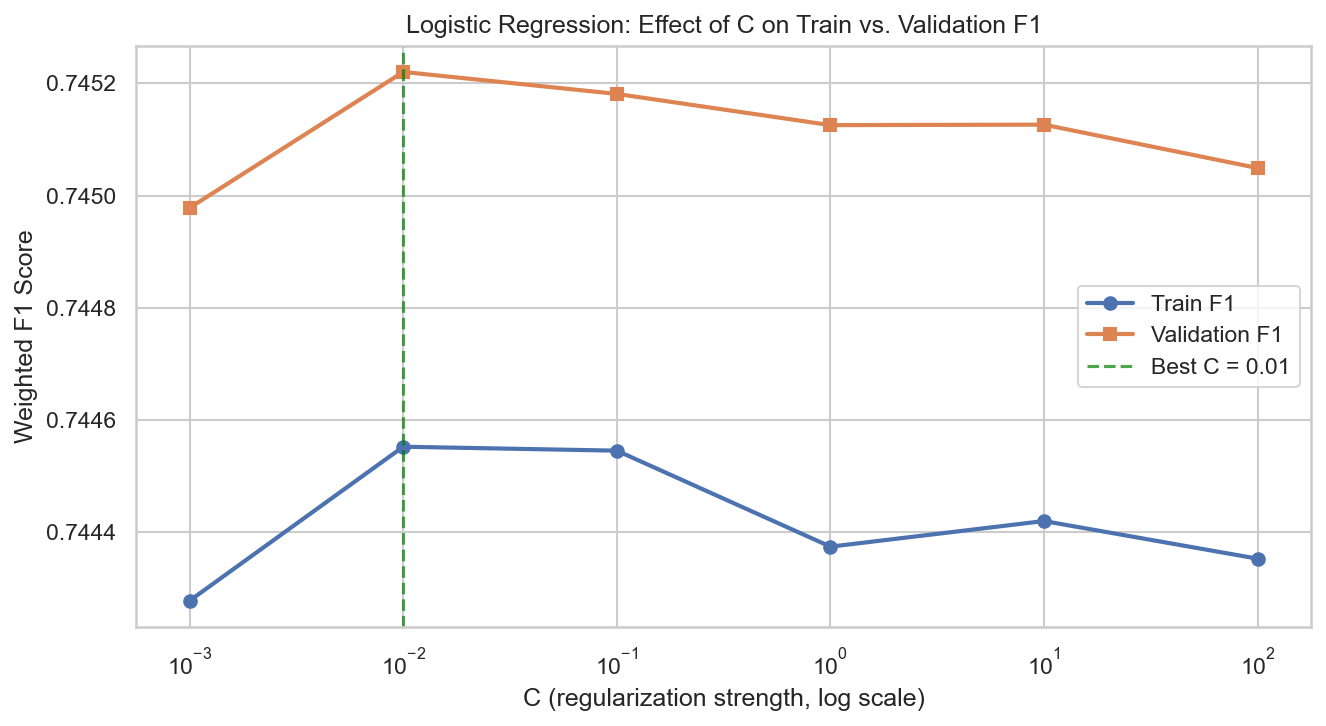

In [31]:
# Plot tuning curve 
fig, ax = plt.subplots(figsize=(9, 5))
ax.semilogx(lr_tuning_df['C'], lr_tuning_df['train_f1'],
            marker='o', label='Train F1', color='#4C72B0', linewidth=2)
ax.semilogx(lr_tuning_df['C'], lr_tuning_df['val_f1'],
            marker='s', label='Validation F1', color='#DD8452', linewidth=2)
ax.axvline(best_C, linestyle='--', color='green', alpha=0.7, label=f'Best C = {best_C}')
ax.set_xlabel('C (regularization strength, log scale)')
ax.set_ylabel('Weighted F1 Score')
ax.set_title('Logistic Regression: Effect of C on Train vs. Validation F1')
ax.legend()
plt.tight_layout()
plt.show()


### Logistic Regression — Best Model Evaluation

Using the best `C` found during tuning, we retrain on the full training set and evaluate on both validation and test sets. We evaluate on the **test set only once** to get an unbiased estimate of generalization performance.


-------------------------------------------------------
  Logistic Regression — Validation Performance
-------------------------------------------------------
  Accuracy         : 0.7123  misleading due to imbalance
  Weighted F1      : 0.7452  PRIMARY METRIC
  Macro F1         : 0.6059  treats both classes equally
  Precision (wtd)  : 0.8098
  Recall    (wtd)  : 0.7123
  ROC-AUC          : 0.7045

Classification Report:
              precision    recall  f1-score   support

Not Arrested       0.91      0.73      0.81    182506
    Arrested       0.30      0.60      0.40     34718

    accuracy                           0.71    217224
   macro avg       0.60      0.67      0.61    217224
weighted avg       0.81      0.71      0.75    217224



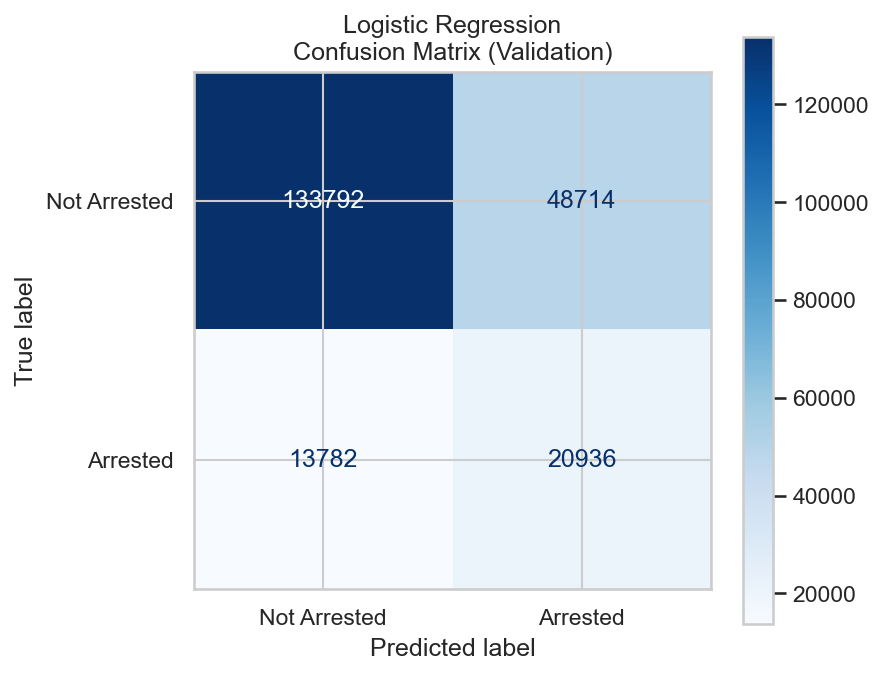


-------------------------------------------------------
  Logistic Regression — Test Performance
-------------------------------------------------------
  Accuracy         : 0.7120  misleading due to imbalance
  Weighted F1      : 0.7450  PRIMARY METRIC
  Macro F1         : 0.6055  treats both classes equally
  Precision (wtd)  : 0.8094
  Recall    (wtd)  : 0.7120
  ROC-AUC          : 0.7029

Classification Report:
              precision    recall  f1-score   support

Not Arrested       0.91      0.73      0.81    182507
    Arrested       0.30      0.60      0.40     34718

    accuracy                           0.71    217225
   macro avg       0.60      0.67      0.61    217225
weighted avg       0.81      0.71      0.74    217225



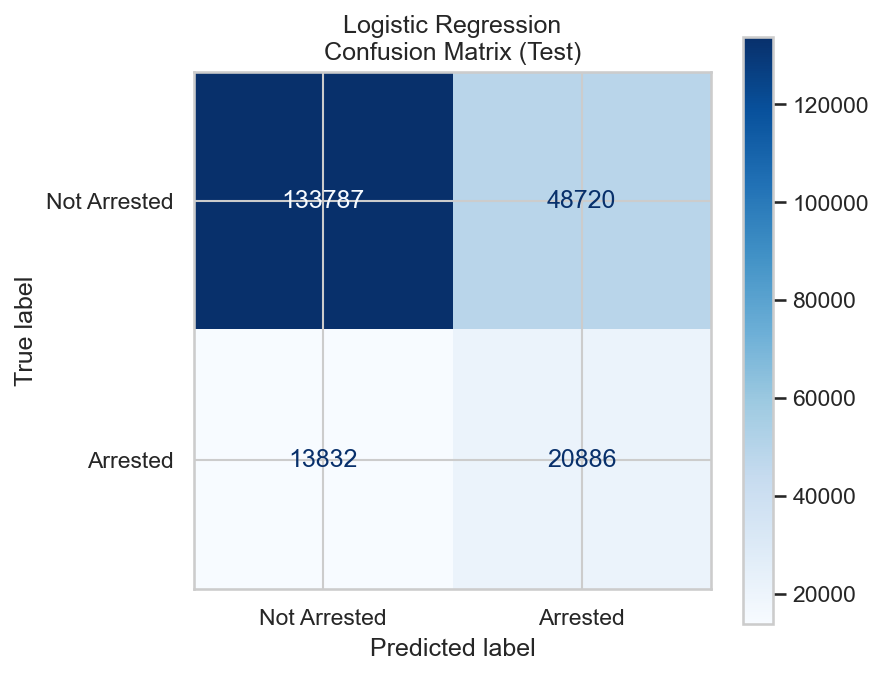

In [32]:
# Train best Logistic Regression
best_lr = LogisticRegression(
    C=best_C,
    class_weight='balanced',
    max_iter=1000,
    random_state=42,
    solver='lbfgs'
)
best_lr.fit(X_train, y_train)

# Evaluate on validation
lr_val_scores  = evaluate_model(best_lr, X_val,  y_val,  'Validation', 'Logistic Regression')

# Evaluate on test (only once — final score)
lr_test_scores = evaluate_model(best_lr, X_test, y_test, 'Test',       'Logistic Regression')

#### Logistic Regression — Coefficient Interpretation

The key strength of Logistic Regression is interpretability. Each coefficient tells us:
- **Positive coefficient** → feature increases probability of arrest
- **Negative coefficient** → feature decreases probability of arrest
- **Magnitude** → how strongly the feature influences the prediction

This is where the sociology comes back in — we can directly ask: *does the `domestic` flag increase or decrease arrest likelihood, and by how much relative to other features?*

Interpretation:'domestic' coefficient = 0.3141, which means domestic crimes are MORE likely to result in arrest, which challenges the common finding that domestic violence incidents result in fewer arrests due to victim reluctance, mandatory arrest policies, or police discretion.

,feature,coefficient
9,domestic,0.318518
10,fbi_code_encoded,0.088229
4,is_weekend,0.048658
0,hour,0.020496
11,iucr_encoded,0.017830
2,month,-0.017816
3,season_encoded,0.013815
1,day_of_week,0.008693
6,district,-0.007960
7,location_description_encoded,0.004382


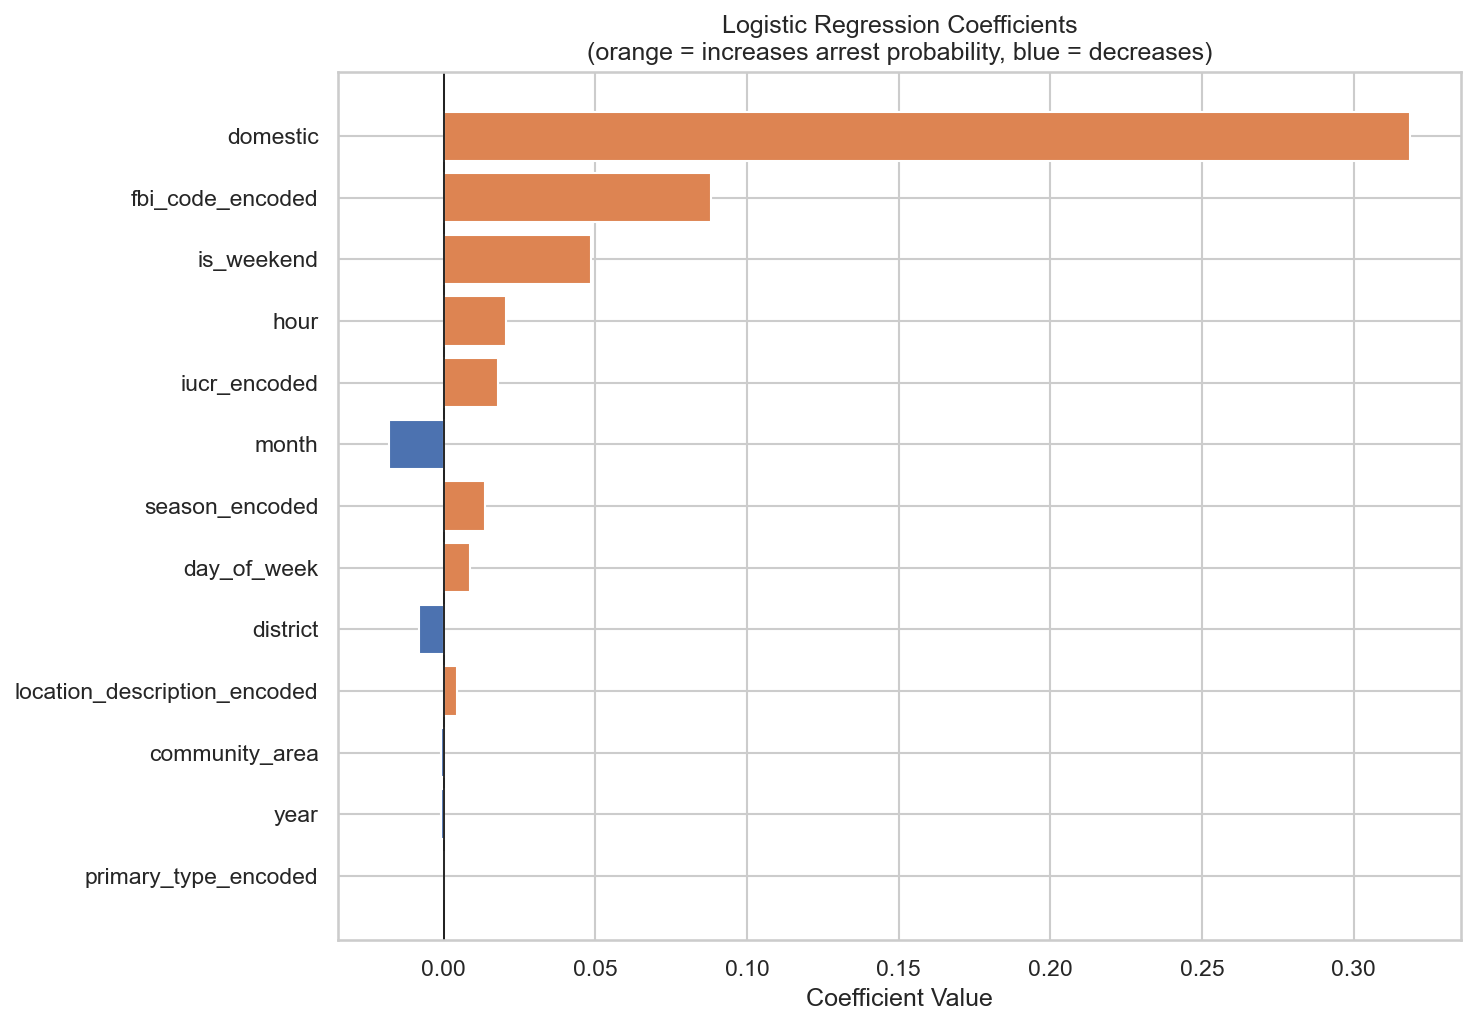

In [33]:
# Coefficient analysis
feature_names = X_train.columns.tolist()
coef_df = pd.DataFrame({
    'feature'    : feature_names,
    'coefficient': best_lr.coef_[0]
}).sort_values('coefficient', key=abs, ascending=False)

display(coef_df)

fig, ax = plt.subplots(figsize=(10, 7))
colors = ['#DD8452' if c > 0 else '#4C72B0' for c in coef_df['coefficient']]
ax.barh(coef_df['feature'][::-1], coef_df['coefficient'][::-1], color=colors[::-1])
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Coefficient Value')
ax.set_title('Logistic Regression Coefficients\n(orange = increases arrest probability, blue = decreases)')
plt.tight_layout()
plt.show()

domestic_coef = coef_df[coef_df['feature'] == 'domestic']['coefficient'].values[0]

### MODEL 2: Random Forest (Tree-Based Model)

Random Forest can capture **non-linear relationships** and **feature interactions** (domestic crimes at night in certain districts may behave differently from domestic crimes during the day)
- It is naturally robust to outliers and does not require feature scaling
- Feature importance scores provide an alternative, non-linear measure of which variables drive arrest predictions
- It handles class imbalance via `class_weight='balanced'`

#### Parameters Tuned

| Parameter | What it controls | Effect of increasing |
|---|---|---|
| `n_estimators` | Number of trees | More trees = more stable, diminishing returns after ~200 |
| `max_depth` | How deep each tree grows | Deeper = more complex = risk of overfitting |
| `min_samples_leaf` | Min samples required at a leaf | Larger = simpler trees = less overfitting |

We tune these **one at a time** so we can clearly see the effect of each parameter — a more transparent process than a black-box grid search.

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
# Random Forest — Hyperparameter Tuning with RandomizedSearchCV

param_dist = {
    'n_estimators'     : [50, 100, 200, 300],
    'max_depth'        : [5, 10, 20, 30, None],
    'min_samples_leaf' : [1, 5, 10, 50, 100],
    'max_features'     : ['sqrt', 'log2']     # features per split
}

rf_base = RandomForestClassifier(
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

search = RandomizedSearchCV(
    estimator=rf_base,
    param_distributions=param_dist,
    n_iter=20,              # test 20 random combinations
    scoring='f1_weighted',  # consistent with our primary metric
    cv=3,                   # 3-fold cross-validation on training set
    random_state=42,
    n_jobs=-1,
    verbose=1,
    return_train_score=True
)

search.fit(X_train, y_train)

# --- Show all results sorted by val performance ---
results_df = pd.DataFrame(search.cv_results_)[
    ['param_n_estimators', 'param_max_depth', 'param_min_samples_leaf',
     'param_max_features', 'mean_train_score', 'mean_test_score', 'std_test_score']
].sort_values('mean_test_score', ascending=False)

print('All combinations tested (sorted by CV F1):')
display(results_df)

print(f'\nBest parameters found:')
print(search.best_params_)
print(f'Best CV F1 (weighted): {search.best_score_:.4f}')

# --- Evaluate best model on validation set ---
best_rf = search.best_estimator_
val_f1 = f1_score(y_val, best_rf.predict(X_val), average='weighted')
print(f'Validation F1 with best params: {val_f1:.4f}')

Fitting 3 folds for each of 20 candidates, totalling 60 fits
All combinations tested (sorted by CV F1):


,param_n_estimators,param_max_depth,param_min_samples_leaf,param_max_features,mean_train_score,mean_test_score,std_test_score
11,200,None,1,log2,0.998641,0.899011,0.000451
18,200,20,1,sqrt,0.964324,0.892262,0.000168
14,200,None,5,log2,0.943947,0.887927,0.000073
12,100,None,5,sqrt,0.943089,0.887444,0.000139
7,200,None,10,sqrt,0.910759,0.874805,0.000154
4,50,30,10,sqrt,0.908763,0.873447,0.000566
8,200,None,50,sqrt,0.857438,0.847570,0.000305
17,50,30,50,log2,0.857135,0.847450,0.000576
0,300,20,50,sqrt,0.856688,0.847287,0.000246
5,300,20,50,log2,0.856688,0.847287,0.000246



Best parameters found:
{'n_estimators': 200, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': None}
Best CV F1 (weighted): 0.8990
Validation F1 with best params: 0.8986


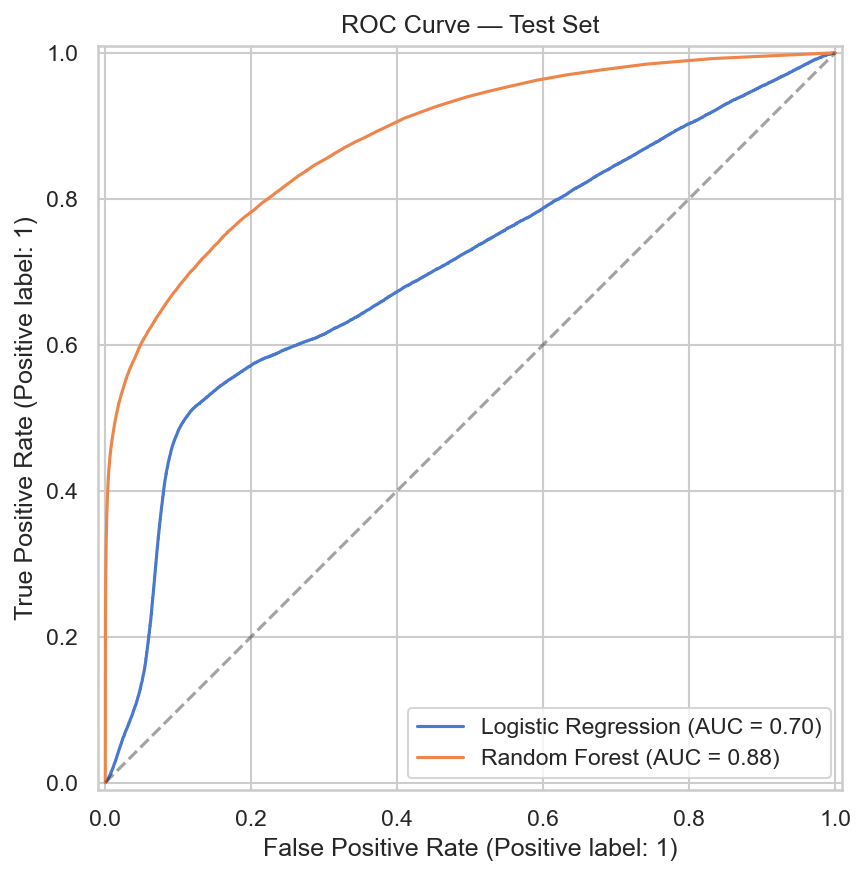

In [35]:
from sklearn.metrics import RocCurveDisplay

fig, ax = plt.subplots(figsize=(7, 6))
RocCurveDisplay.from_estimator(best_lr, X_test, y_test, ax=ax, name="Logistic Regression")
RocCurveDisplay.from_estimator(best_rf, X_test, y_test, ax=ax, name="Random Forest")
ax.plot([0,1],[0,1], 'k--', alpha=0.4)
ax.set_title("ROC Curve — Test Set")
plt.tight_layout()
plt.show()

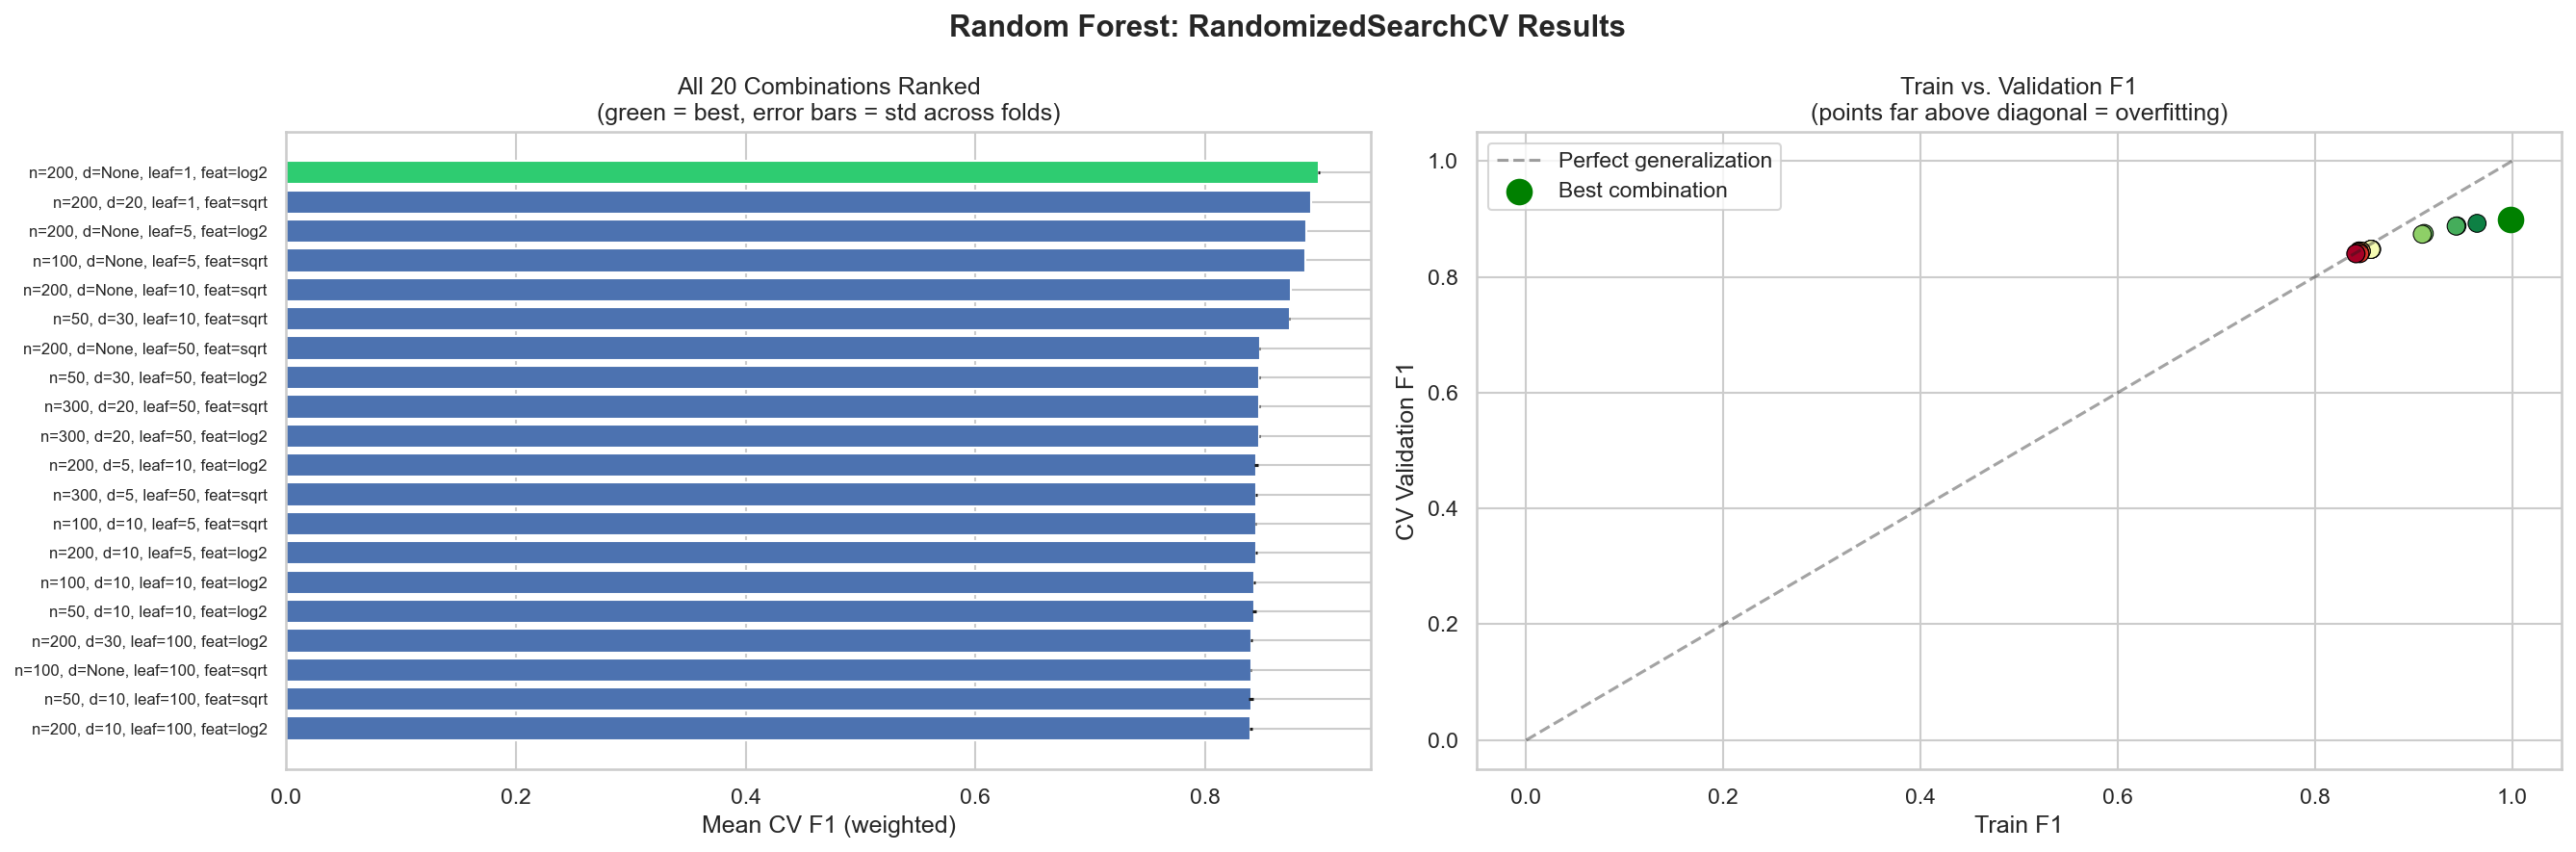


Best combination (green bar):
  {'n_estimators': 200, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': None}
  CV F1: 0.8990


In [36]:
# --- Visualize RandomizedSearchCV results ---
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle('Random Forest: RandomizedSearchCV Results', fontsize=15, fontweight='bold')

# Chart 1: All 20 combinations ranked by CV F1
axes[0].barh(
    range(len(results_df)),
    results_df['mean_test_score'],
    xerr=results_df['std_test_score'],
    color=['#2ecc71' if i == 0 else '#4C72B0' for i in range(len(results_df))],
    edgecolor='white'
)
axes[0].set_yticks(range(len(results_df)))
axes[0].set_yticklabels(
    [f"n={r['param_n_estimators']}, d={r['param_max_depth']}, "
     f"leaf={r['param_min_samples_leaf']}, feat={r['param_max_features']}"
     for _, r in results_df.iterrows()],
    fontsize=8
)
axes[0].set_xlabel('Mean CV F1 (weighted)')
axes[0].set_title('All 20 Combinations Ranked\n(green = best, error bars = std across folds)')
axes[0].invert_yaxis()

# Chart 2: Train vs CV F1 for each combination (overfitting check)
axes[1].scatter(
    results_df['mean_train_score'],
    results_df['mean_test_score'],
    c=range(len(results_df)),
    cmap='RdYlGn_r',
    s=80, edgecolors='black', linewidths=0.5
)
axes[1].plot([0, 1], [0, 1], 'k--', alpha=0.4, label='Perfect generalization')
axes[1].set_xlabel('Train F1')
axes[1].set_ylabel('CV Validation F1')
axes[1].set_title('Train vs. Validation F1\n(points far above diagonal = overfitting)')
axes[1].legend()

# Highlight best combination
best_row = results_df.iloc[0]
axes[1].scatter(
    best_row['mean_train_score'],
    best_row['mean_test_score'],
    color='green', s=150, zorder=5, label='Best combination'
)
axes[1].legend()

plt.tight_layout()
plt.savefig('rf_randomsearch_results.png', bbox_inches='tight')
plt.show()

print(f"\nBest combination (green bar):")
print(f"  {search.best_params_}")
print(f"  CV F1: {search.best_score_:.4f}")

#### Best Model Evaluation

Best RF parameters: {'n_estimators': 200, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': None}

-------------------------------------------------------
  Random Forest — Validation Performance
-------------------------------------------------------
  Accuracy         : 0.9081  misleading due to imbalance
  Weighted F1      : 0.8986  PRIMARY METRIC
  Macro F1         : 0.7950  treats both classes equally
  Precision (wtd)  : 0.9040
  Recall    (wtd)  : 0.9081
  ROC-AUC          : 0.8849

Classification Report:
              precision    recall  f1-score   support

Not Arrested       0.91      0.98      0.95    182506
    Arrested       0.85      0.52      0.64     34718

    accuracy                           0.91    217224
   macro avg       0.88      0.75      0.80    217224
weighted avg       0.90      0.91      0.90    217224



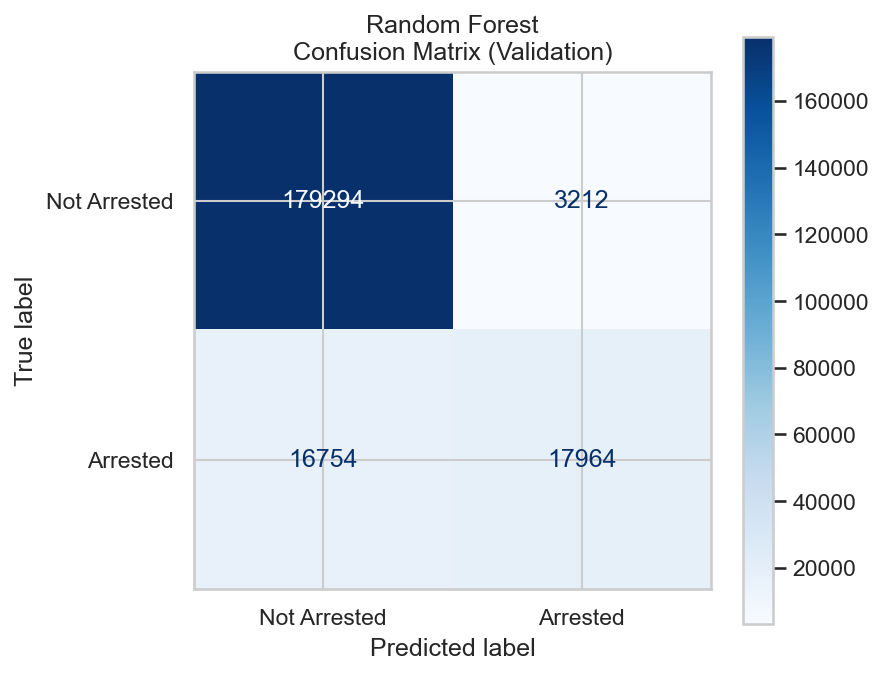


-------------------------------------------------------
  Random Forest — Test Performance
-------------------------------------------------------
  Accuracy         : 0.9077  misleading due to imbalance
  Weighted F1      : 0.8982  PRIMARY METRIC
  Macro F1         : 0.7941  treats both classes equally
  Precision (wtd)  : 0.9036
  Recall    (wtd)  : 0.9077
  ROC-AUC          : 0.8842

Classification Report:
              precision    recall  f1-score   support

Not Arrested       0.91      0.98      0.95    182507
    Arrested       0.85      0.52      0.64     34718

    accuracy                           0.91    217225
   macro avg       0.88      0.75      0.79    217225
weighted avg       0.90      0.91      0.90    217225



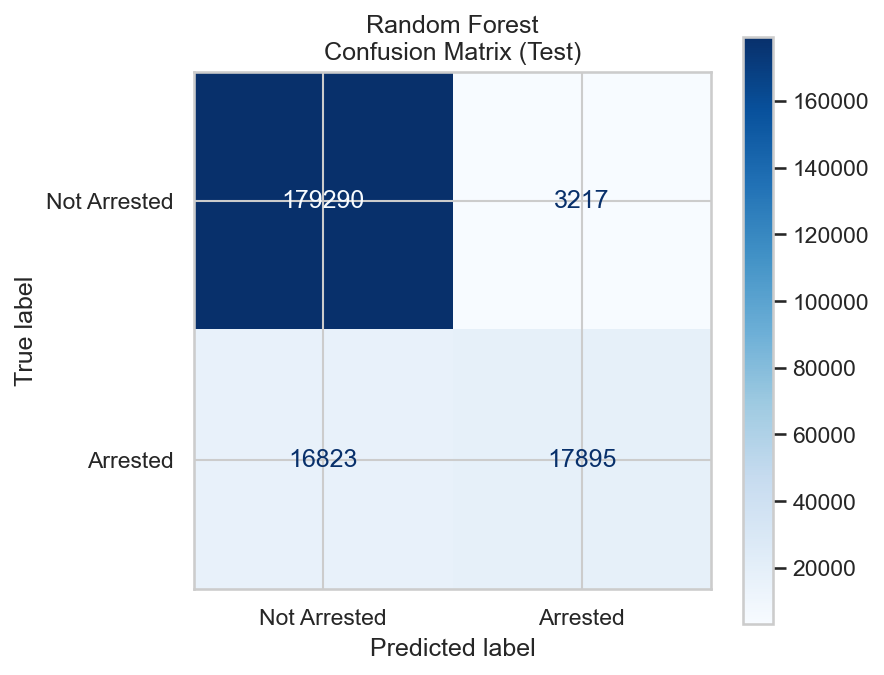

In [37]:
print(f"Best RF parameters: {search.best_params_}")
rf_val_scores  = evaluate_model(best_rf, X_val,  y_val,  'Validation', 'Random Forest')
rf_test_scores = evaluate_model(best_rf, X_test, y_test, 'Test',       'Random Forest')

### Feature Importance
Comparing feature importance between models tells us whether the same features drive predictions in both the linear and non-linear frameworks — if they agree, we can be more confident in the sociological interpretation.

,feature,importance
11,iucr_encoded,0.186691
10,fbi_code_encoded,0.154657
0,hour,0.108746
7,location_description_encoded,0.095329
5,community_area,0.093769
8,primary_type_encoded,0.071730
6,district,0.064904
2,month,0.063675
1,day_of_week,0.058566
12,year,0.050665


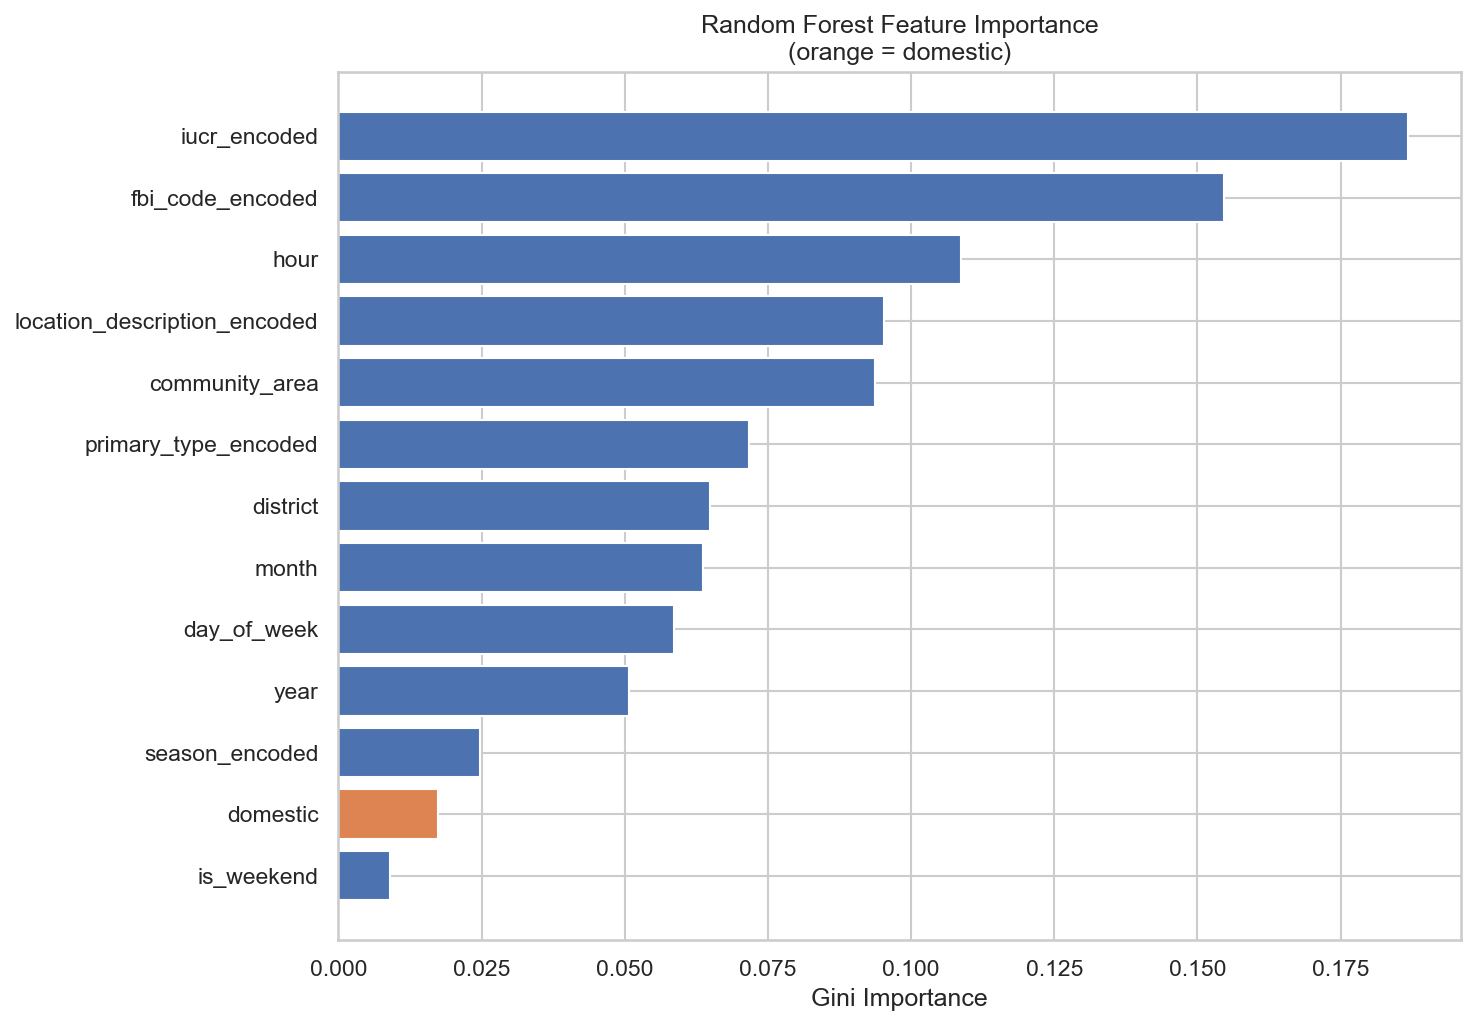

In [38]:
# Feature importance 
feat_imp = pd.DataFrame({
    'feature'   : X_train.columns,
    'importance': best_rf.feature_importances_
}).sort_values('importance', ascending=False)

display(feat_imp)

fig, ax = plt.subplots(figsize=(10, 7))
colors = ['#DD8452' if f == 'domestic' else '#4C72B0' for f in feat_imp['feature']]
ax.barh(feat_imp['feature'][::-1], feat_imp['importance'][::-1], color=colors[::-1])
ax.set_xlabel('Gini Importance')
ax.set_title('Random Forest Feature Importance\n(orange = domestic)')
plt.tight_layout()
plt.savefig('rf_feature_importance.png', bbox_inches='tight')
plt.show()

domestic_rank = feat_imp['feature'].tolist().index('domestic') + 1


### MODEL 3: K-Means Clustering (Unsupervised Model)

K-Means is applied at the **community area level** rather than the individual incident level. We aggregate crime statistics per community area (domestic crime rate, arrest rate, crime volume...) and cluster areas into typologies.

#### Parameter Tuned: `k` (number of clusters)

We use the **Elbow Method** (inertia) and **Silhouette Score** to find the optimal k:
- **Inertia** — total within-cluster variance; lower is better but always decreases with more k
- **Silhouette Score** — how well-separated clusters are; ranges -1 to 1, higher is better
- The **elbow** is where adding more clusters gives diminishing returns

In [39]:
from sklearn.metrics import silhouette_score

# We need the original df — reload it
df = pd.read_csv('data/chicago_crimes_2018_2023.csv')
df['arrest']   = df['arrest'].astype(str).str.upper().map({'TRUE':1,'FALSE':0,'1':1,'0':0,'1.0':1,'0.0':0})
df['domestic'] = df['domestic'].astype(str).str.upper().map({'TRUE':1,'FALSE':0,'1':1,'0':0,'1.0':1,'0.0':0})
df = df.dropna(subset=['arrest','domestic','community_area'])
df['community_area'] = df['community_area'].astype(int)
df = df[df['community_area'].between(1,77)]

# Date features
df['date']   = pd.to_datetime(df['date'])
df['hour']   = df['date'].dt.hour
df['is_weekend'] = df['date'].dt.dayofweek.isin([5,6]).astype(int)

ca_features = df.groupby('community_area').agg(
    total_crimes      = ('arrest', 'count'),
    arrest_rate       = ('arrest', 'mean'),
    domestic_rate     = ('domestic', 'mean'),
    avg_hour          = ('hour', 'mean'),
    weekend_rate      = ('is_weekend', 'mean'),
).reset_index()

print(f'feature matrix: {ca_features.shape}')
display(ca_features.head())

feature matrix: (77, 6)


,community_area,total_crimes,arrest_rate,domestic_rate,avg_hour,weekend_rate
0,1,23324,0.138312,0.161679,12.710127,0.273409
1,2,21177,0.099259,0.163479,12.866789,0.272277
2,3,21741,0.132009,0.127823,12.770342,0.270181
3,4,11600,0.105431,0.113190,12.566810,0.266121
4,5,7686,0.076373,0.082488,12.545277,0.255530


In [40]:
# Scale features
cluster_features = ['total_crimes', 'arrest_rate', 'domestic_rate', 'avg_hour', 'weekend_rate']
scaler = StandardScaler()
X_cluster = scaler.fit_transform(ca_features[cluster_features])

# Elbow method + silhouette 
k_values    = range(2, 9)
inertias    = []
silhouettes = []

for k in k_values:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_cluster)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_cluster, labels))

best_k = k_values[np.argmax(silhouettes)]
print(best_k)


3


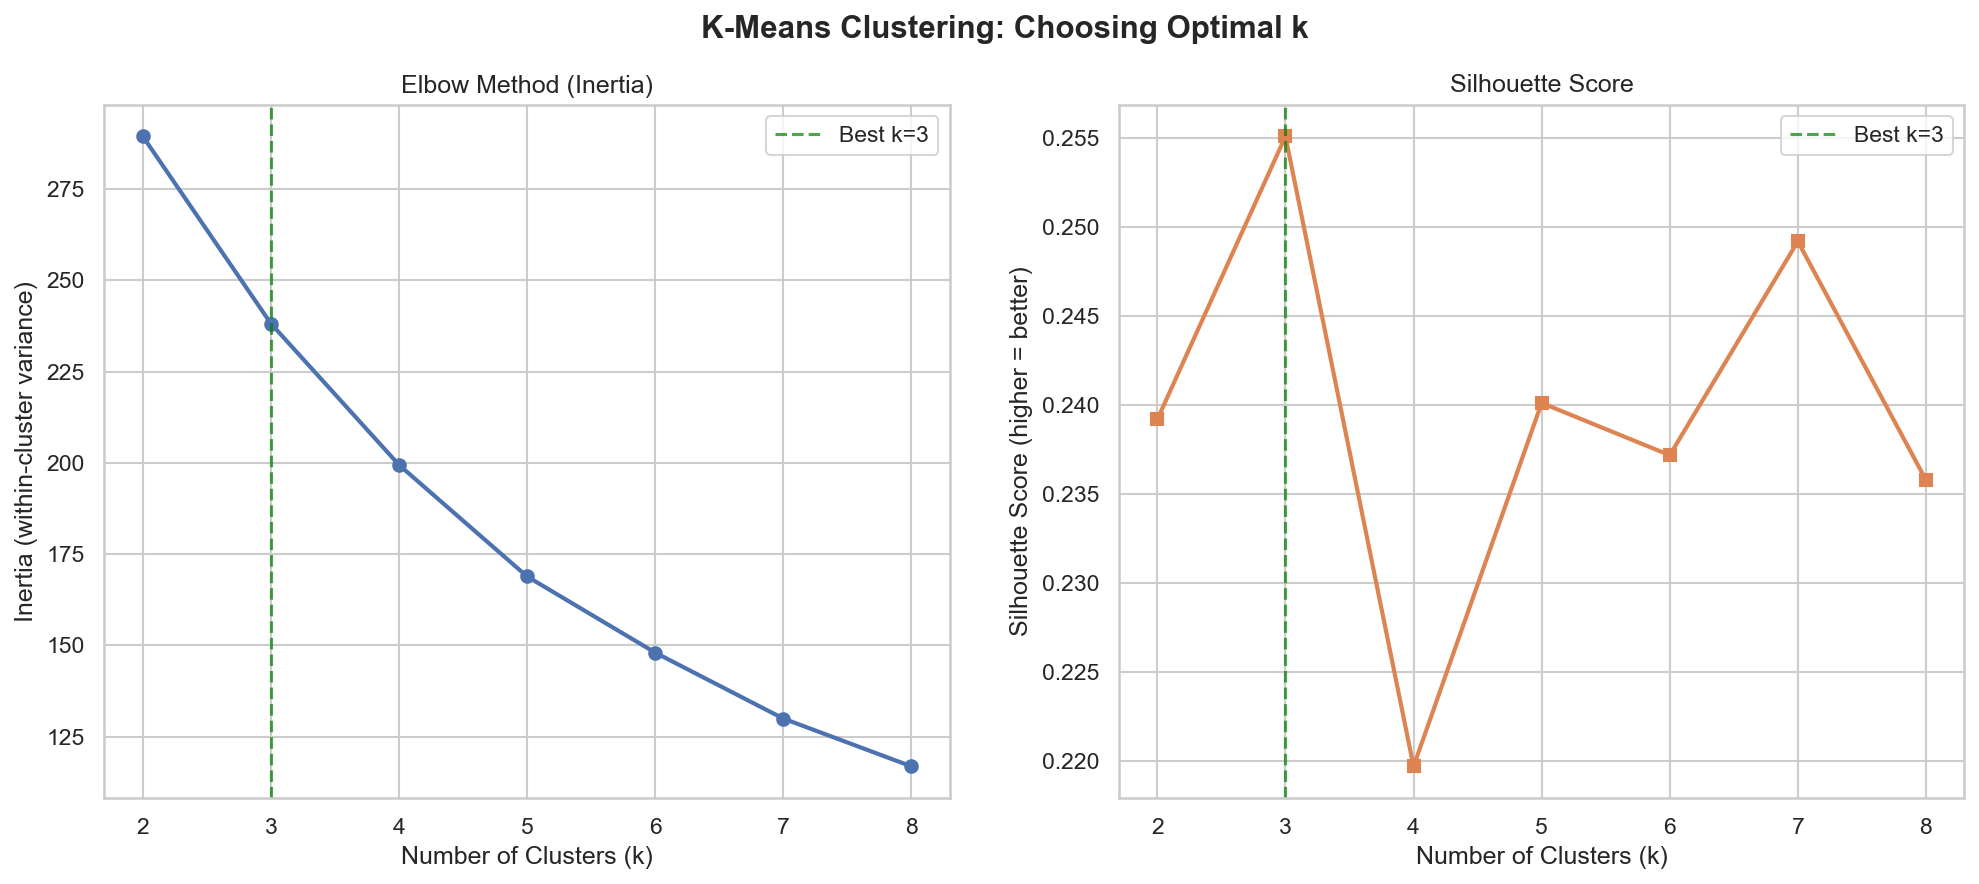

In [41]:
# Plot elbow + silhouette 
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('K-Means Clustering: Choosing Optimal k', fontsize=15, fontweight='bold')

axes[0].plot(list(k_values), inertias, marker='o', color='#4C72B0', linewidth=2)
axes[0].set_title('Elbow Method (Inertia)')
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Inertia (within-cluster variance)')
axes[0].axvline(best_k, linestyle='--', color='green', alpha=0.7, label=f'Best k={best_k}')
axes[0].legend()

axes[1].plot(list(k_values), silhouettes, marker='s', color='#DD8452', linewidth=2)
axes[1].set_title('Silhouette Score')
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Silhouette Score (higher = better)')
axes[1].axvline(best_k, linestyle='--', color='green', alpha=0.7, label=f'Best k={best_k}')
axes[1].legend()

plt.show()

#### Each cluster represents a neighborhood typology

- High domestic rate + low arrest rate → possible under-policing of domestic violence 

- High total crimes + high arrest rate → heavily policed areas 

- Low crime + low domestic rate → relatively stable, low-risk communities



Cluster profiles (mean values per cluster):


,total_crimes,arrest_rate,domestic_rate,avg_hour,weekend_rate
cluster,,,,,
0,27316.214,0.183,0.259,12.716,0.290
1,9610.050,0.114,0.178,12.530,0.275
2,34119.444,0.120,0.087,12.861,0.297



Number of community areas per cluster:
cluster
0    28
1    40
2     9


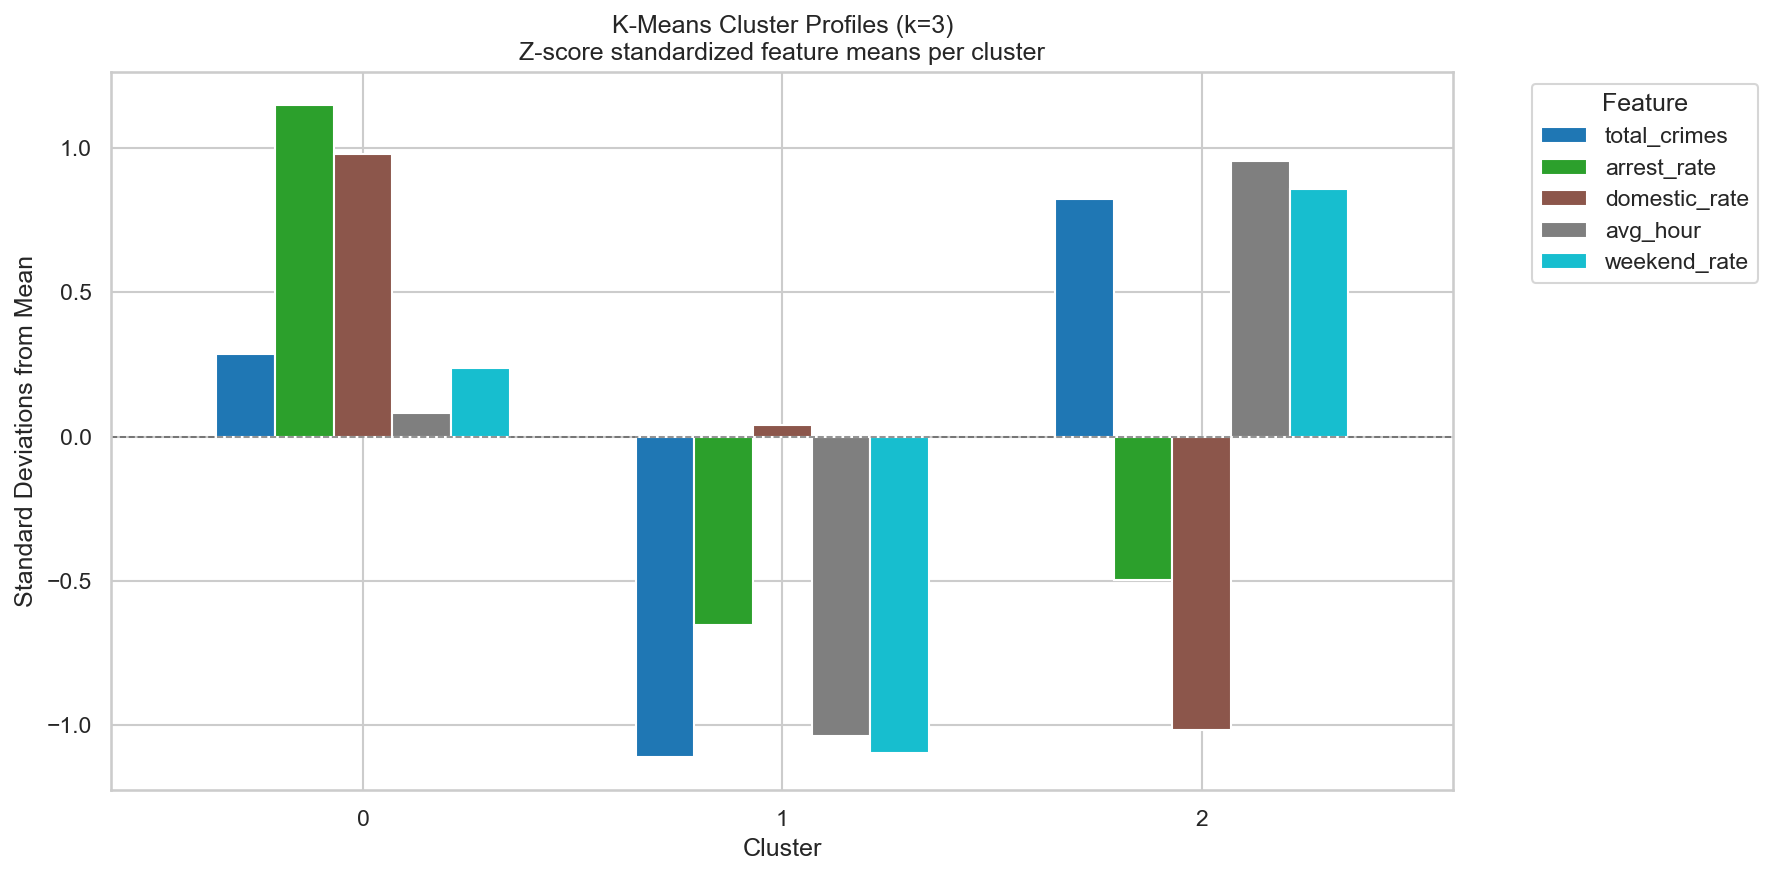

In [55]:
# --- 3e. Fit best K-Means and interpret clusters ---
best_km = KMeans(n_clusters=best_k, random_state=42, n_init=10)
ca_features['cluster'] = best_km.fit_predict(X_cluster)

print(f'\nCluster profiles (mean values per cluster):')
cluster_profile = ca_features.groupby('cluster')[cluster_features].mean().round(3)
display(cluster_profile)

print(f'\nNumber of community areas per cluster:')
print(ca_features['cluster'].value_counts().sort_index().to_string())

# Visualize cluster profiles — z-score standardization so all clusters are visible
fig, ax = plt.subplots(figsize=(12, 6))
cluster_profile_norm = (cluster_profile - cluster_profile.mean()) / cluster_profile.std()
cluster_profile_norm.plot(kind='bar', ax=ax, colormap='tab10', width=0.7)
ax.set_title(f'K-Means Cluster Profiles (k={best_k})\nZ-score standardized feature means per cluster')
ax.set_ylabel('Standard Deviations from Mean')
ax.set_xlabel('Cluster')
ax.axhline(y=0, color='black', linewidth=0.8, linestyle='--', alpha=0.5)
ax.legend(title='Feature', bbox_to_anchor=(1.05, 1))
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Model Comparison

We compare the two supervised models side by side on the **test set** — the held-out data neither model has seen during training or tuning.

**What to look for:**
- Which model achieves higher weighted F1 and ROC-AUC?
- Is there a large gap between the models, or are they comparable?
- Does the more complex model (Random Forest) justify its added complexity over Logistic Regression?
- Are the feature rankings consistent between models? If both agree on top features, that strengthens the sociological interpretation.

,Accuracy,F1 (weighted),F1 (macro),Precision,Recall,ROC-AUC
Model,,,,,,
Logistic Regression,0.7120,0.7450,0.6055,0.8094,0.7120,0.7029
Random Forest,0.9077,0.8982,0.7941,0.9036,0.9077,0.8842


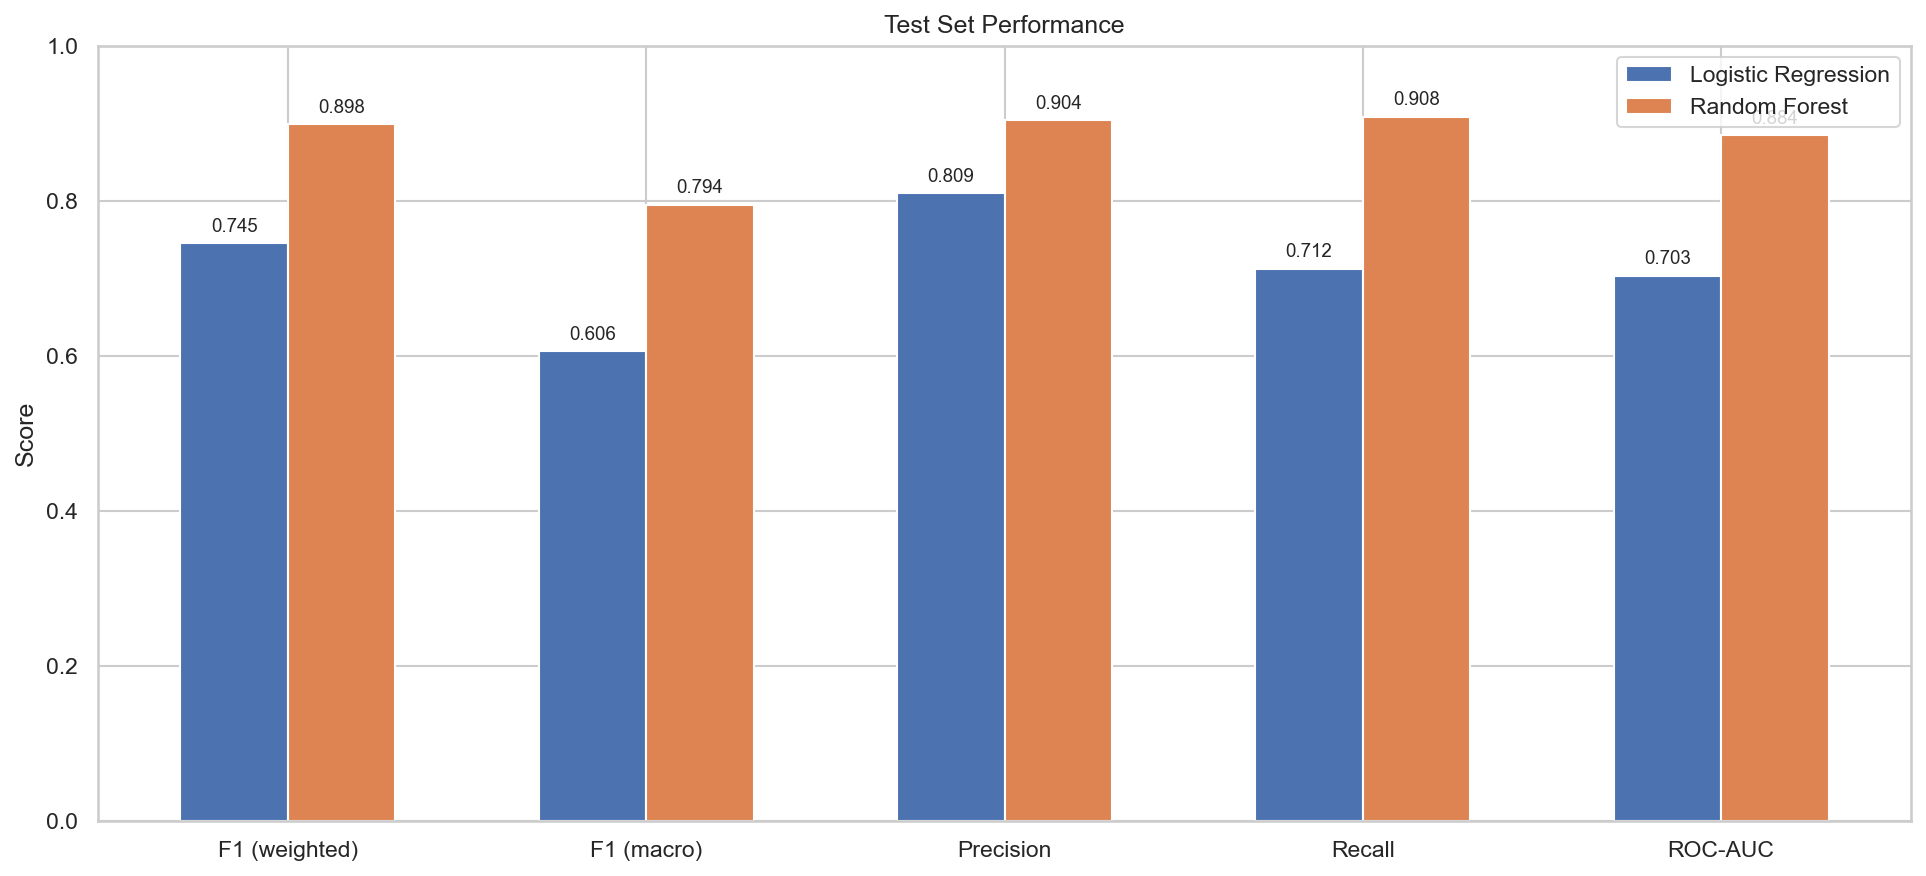

In [43]:
# Comparison table
comparison = pd.DataFrame([lr_test_scores, rf_test_scores])
comparison = comparison[['model', 'accuracy', 'f1_weighted', 'f1_macro', 'precision', 'recall', 'auc']]
comparison.columns = ['Model', 'Accuracy', 'F1 (weighted)', 'F1 (macro)', 'Precision', 'Recall', 'ROC-AUC']
comparison = comparison.set_index('Model').round(4)

display(comparison)

# Bar chart comparison 
metrics = ['F1 (weighted)', 'F1 (macro)', 'Precision', 'Recall', 'ROC-AUC']
x = np.arange(len(metrics))
width = 0.3

fig, ax = plt.subplots(figsize=(13, 6))
ax.bar(x - width/2, comparison.loc['Logistic Regression', metrics], width, label='Logistic Regression', color='#4C72B0')
ax.bar(x + width/2, comparison.loc['Random Forest',       metrics], width, label='Random Forest',       color='#DD8452')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylim(0, 1)
ax.set_ylabel('Score')
ax.set_title('Test Set Performance')
ax.legend()
for bar in ax.patches:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

## Result Analysis

In [44]:
from sklearn.tree         import export_graphviz, plot_tree
from sklearn.metrics      import (
    confusion_matrix, ConfusionMatrixDisplay,
    f1_score, classification_report
)

plt.rcParams['figure.dpi']     = 150
plt.rcParams['font.size']      = 12
plt.rcParams['axes.titlesize'] = 13
sns.set_theme(style='whitegrid', palette='muted')


# Feature names
FEATURE_NAMES = X_test.columns.tolist()

# Get predictions from both models
lr_preds = best_lr.predict(X_test)
rf_preds = best_rf.predict(X_test)

print(f'  Test set size: {len(y_test):,} samples')
print(f'  Feature names: {FEATURE_NAMES}')

  Test set size: 217,225 samples
  Feature names: ['hour', 'day_of_week', 'month', 'season_encoded', 'is_weekend', 'community_area', 'district', 'location_description_encoded', 'primary_type_encoded', 'domestic', 'fbi_code_encoded', 'iucr_encoded', 'year']


### Part 1: Interpret Model Performance

#### 1A. Logistic Regression: Top Coefficients

Logistic Regression coefficients tell us the **log-odds contribution** of each feature to arrest probability:
- A **positive coefficient** means higher values of that feature increase the probability of arrest
- A **negative coefficient** means higher values decrease the probability of arrest
- **Magnitude** reflects how strongly the feature influences the prediction

Because features are on different scales, we report both raw coefficients and note which features dominate. This is the primary interpretive tool for the linear model and directly speaks to our research question about the `domestic` flag's role.

'                     feature  coefficient\n                    domestic     0.318518\n            fbi_code_encoded     0.088229\n                  is_weekend     0.048658\n                        hour     0.020496\n                iucr_encoded     0.017830\n              season_encoded     0.013815\n                 day_of_week     0.008693\nlocation_description_encoded     0.004382\n        primary_type_encoded     0.000292\n                        year    -0.000926\n              community_area    -0.000973\n                    district    -0.007960\n                       month    -0.017816'

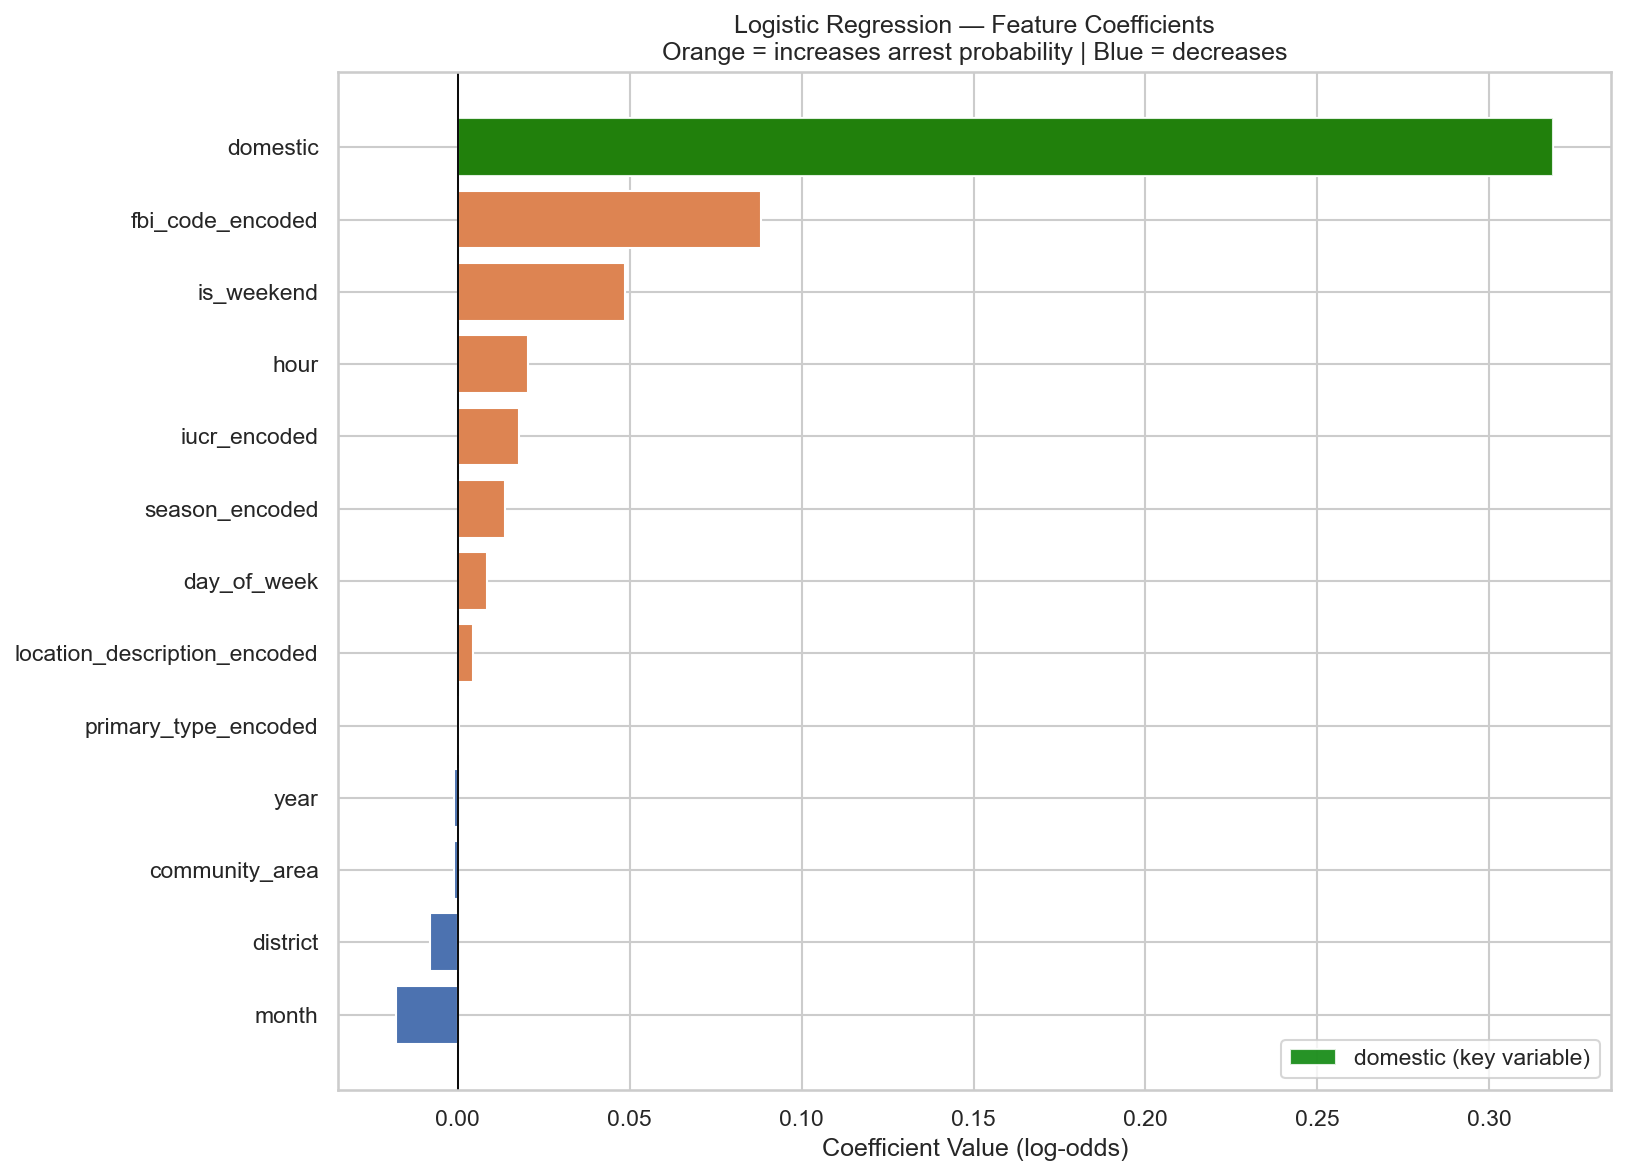

  domestic                            +0.3185  → INCREASES arrest probability
  fbi_code_encoded                    +0.0882  → INCREASES arrest probability
  is_weekend                          +0.0487  → INCREASES arrest probability
  hour                                +0.0205  → INCREASES arrest probability
  iucr_encoded                        +0.0178  → INCREASES arrest probability
  season_encoded                      +0.0138  → INCREASES arrest probability
  day_of_week                         +0.0087  → INCREASES arrest probability
  location_description_encoded        +0.0044  → INCREASES arrest probability
  primary_type_encoded                +0.0003  → INCREASES arrest probability
  year                                -0.0009  → DECREASES arrest probability
  community_area                      -0.0010  → DECREASES arrest probability
  district                            -0.0080  → DECREASES arrest probability
  month                               -0.0178  → DECREASES arres

In [45]:
# Build coefficient dataframe
coef_df = pd.DataFrame({
    'feature'    : FEATURE_NAMES,
    'coefficient': best_lr.coef_[0]
}).sort_values('coefficient', ascending=False)

display(coef_df.to_string(index=False))

# Plot top-n coefficients 
n = 13  
top_n = coef_df.head(n)
bot_n = coef_df.tail(n)
plot_df = pd.concat([top_n, bot_n]).drop_duplicates().sort_values('coefficient')

fig, ax = plt.subplots(figsize=(11, 8))
colors = ['#DD8452' if c > 0 else '#4C72B0' for c in plot_df['coefficient']]
bars = ax.barh(plot_df['feature'], plot_df['coefficient'], color=colors)
ax.axvline(0, color='black', linewidth=0.9)

# Highlight domestic feature
domestic_val = coef_df[coef_df['feature'] == 'domestic']['coefficient'].values[0]
ax.barh('domestic', domestic_val, color='green', alpha=0.85, label='domestic (key variable)')

ax.set_xlabel('Coefficient Value (log-odds)')
ax.set_title('Logistic Regression — Feature Coefficients\nOrange = increases arrest probability | Blue = decreases')
ax.legend()
plt.tight_layout()
plt.savefig('ra_lr_coefficients.png', bbox_inches='tight')
plt.show()

# Interpret each coefficient
for _, row in coef_df.iterrows():
    direction = 'INCREASES' if row['coefficient'] > 0 else 'DECREASES'
    print(f"  {row['feature']:<35} {row['coefficient']:+.4f}  → {direction} arrest probability")

print(f"""
KEY FINDING — 'domestic' coefficient = {domestic_val:+.4f}
{'='*55}
{'→ Domestic crimes are MORE likely to result in arrest' if domestic_val > 0
 else '→ Domestic crimes are LESS likely to result in arrest'}
""")

 Mandatory arrest laws (Illinois requires arrest when probable
  cause exists in domestic violence) may drive higher arrest rates,
  overriding officer discretion — consistent with pro-arrest policy research.


#### 1B. Random Forest — Decision Tree Visualization

Random Forest consists of many trees. To visualize the logic, we:
1. **Visualize a single shallow tree** (max_depth=4) from the forest — this shows the decision rules the model learned in a readable form
2. **Plot full feature importances** from the entire forest — this is the authoritative importance measure

A single tree cannot fully represent the forest's behavior, but it illustrates what features and thresholds the model uses at its top-level splits — which are the most influential decisions.

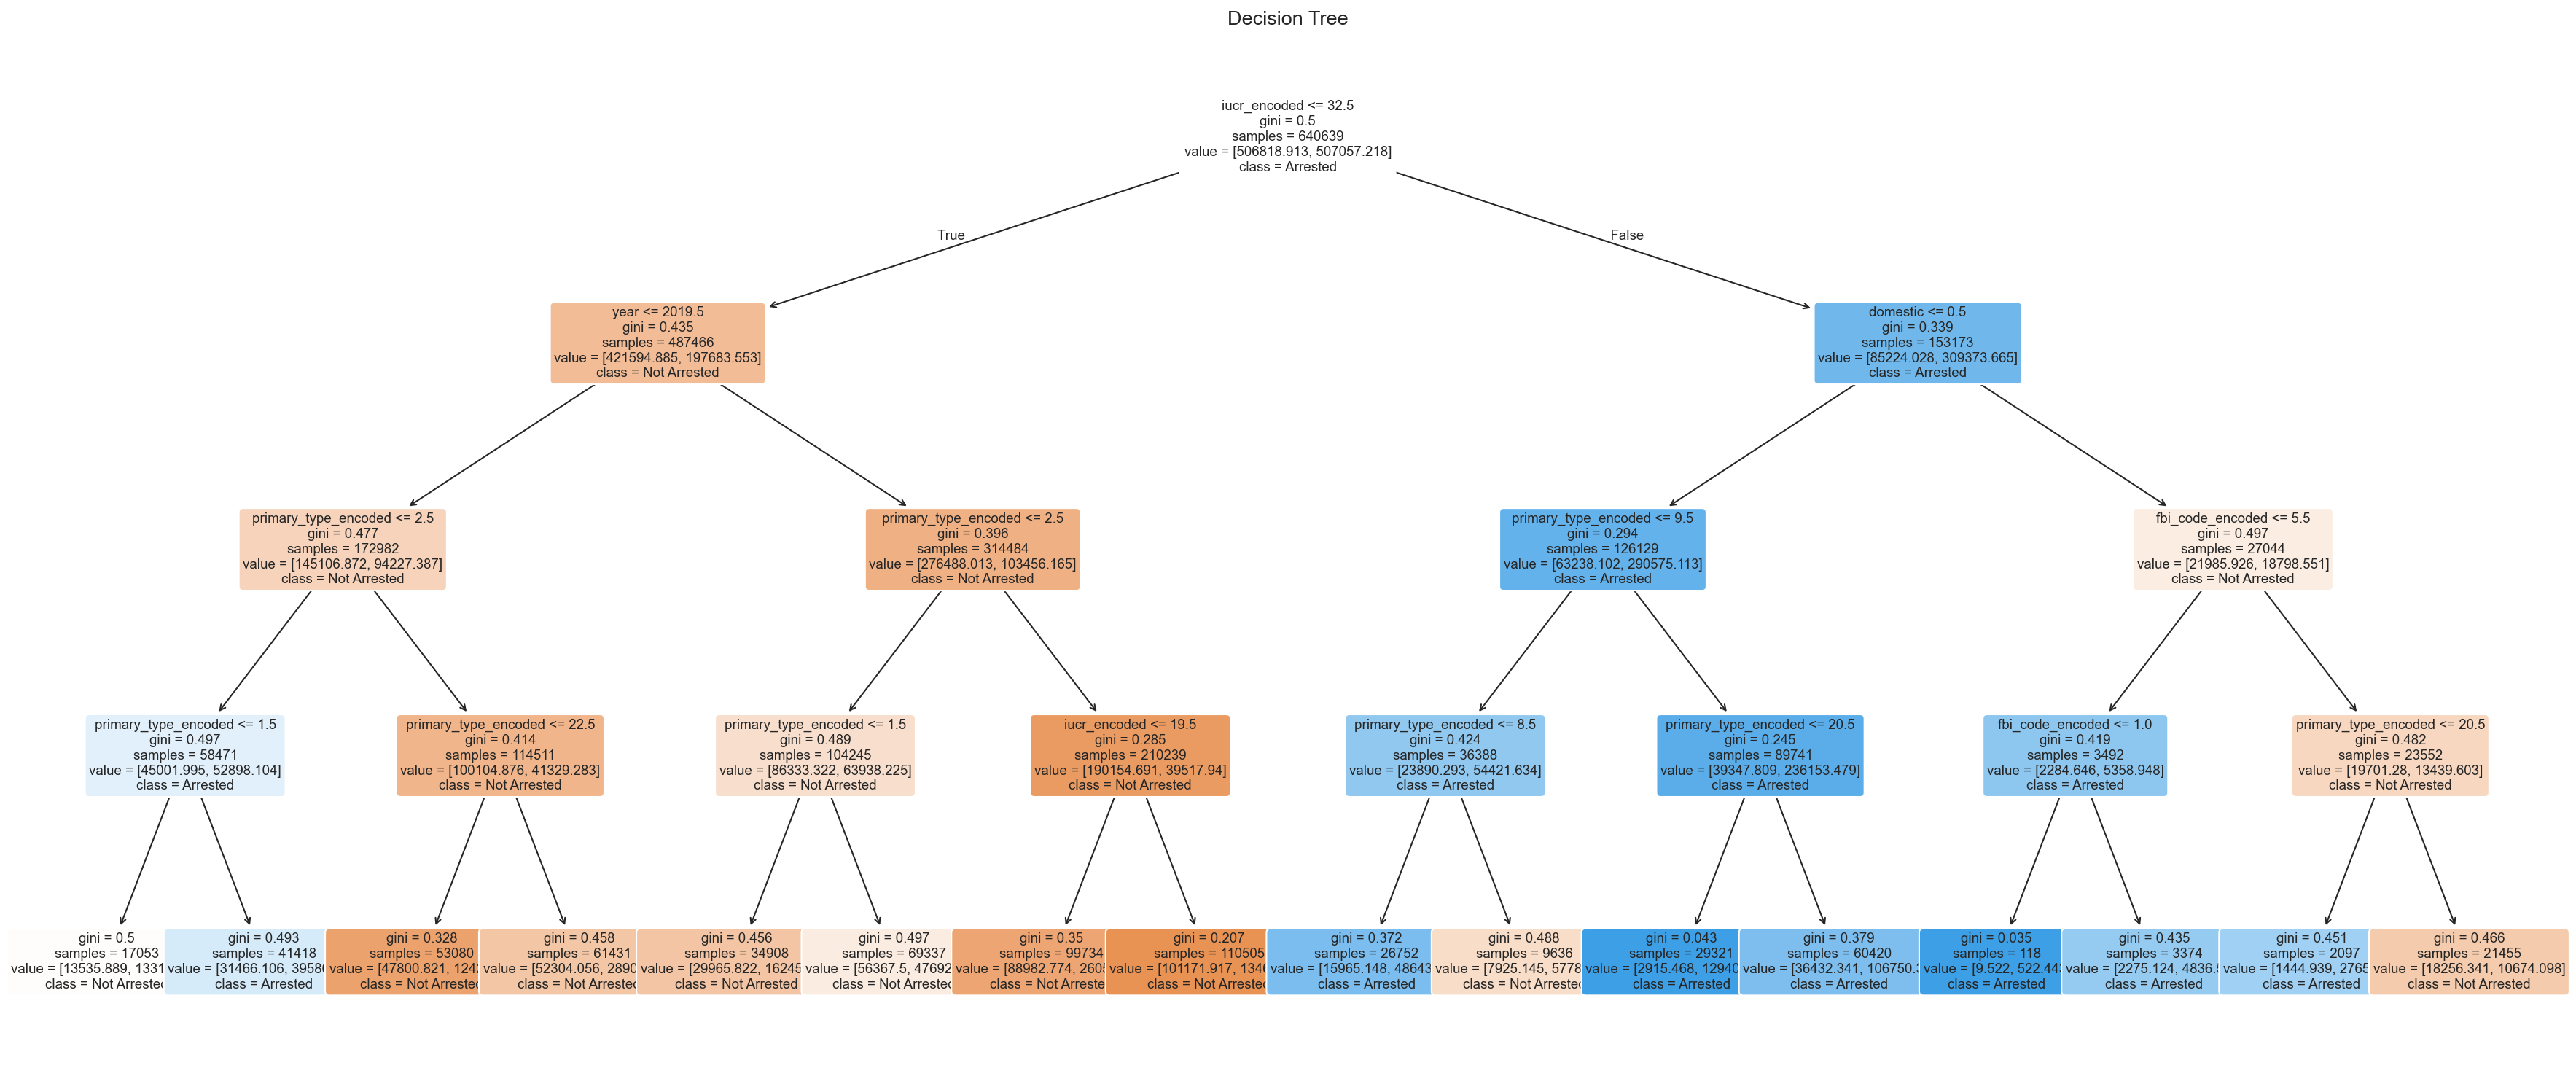

In [46]:
# Visualize one tree from the forest 
from sklearn.ensemble import RandomForestClassifier

# Train a single shallow tree for visualization purposes
viz_tree = RandomForestClassifier(
    n_estimators=1,
    max_depth=4,             
    class_weight='balanced',
    random_state=42
)
viz_tree.fit(X_train, y_train)
single_tree = viz_tree.estimators_[0]

fig, ax = plt.subplots(figsize=(24, 10))
plot_tree(
    single_tree,
    feature_names=FEATURE_NAMES,
    class_names=['Not Arrested', 'Arrested'],
    filled=True,
    rounded=True,
    fontsize=9,
    ax=ax,
    impurity=True,
    proportion=False
)
ax.set_title(
    'Decision Tree',
    fontsize=13
)
plt.tight_layout()
plt.show()



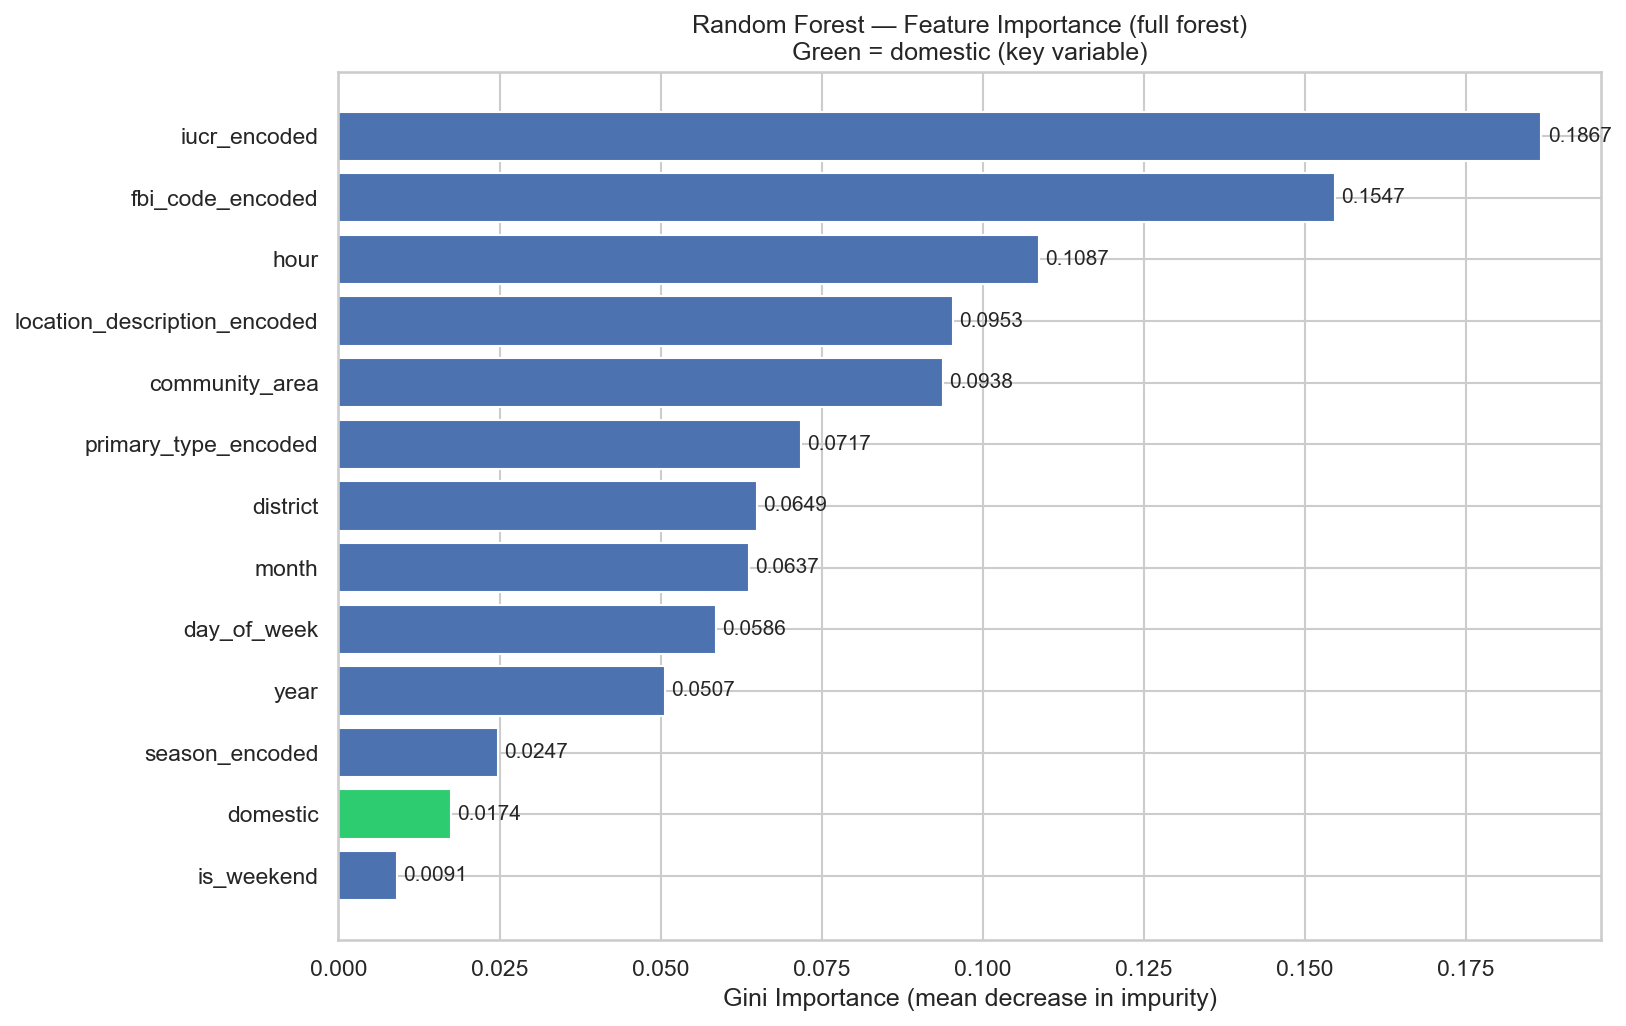

In [47]:
# Full forest feature importance 
feat_imp = pd.DataFrame({
    'feature'   : FEATURE_NAMES,
    'importance': best_rf.feature_importances_
}).sort_values('importance', ascending=False)

fig, ax = plt.subplots(figsize=(11, 7))
colors = ['#2ecc71' if f == 'domestic' else '#4C72B0' for f in feat_imp['feature']]
ax.barh(feat_imp['feature'][::-1], feat_imp['importance'][::-1], color=colors[::-1])
ax.set_xlabel('Gini Importance (mean decrease in impurity)')
ax.set_title('Random Forest — Feature Importance (full forest)\nGreen = domestic (key variable)')

# Add value labels
for i, (imp, feat) in enumerate(zip(feat_imp['importance'][::-1], feat_imp['feature'][::-1])):
    ax.text(imp + 0.001, i, f'{imp:.4f}', va='center', fontsize=10)

plt.tight_layout()
plt.show()

domestic_rank = feat_imp['feature'].tolist().index('domestic') + 1
domestic_imp  = feat_imp[feat_imp['feature'] == 'domestic']['importance'].values[0]
top_feature   = feat_imp.iloc[0]['feature']



## Error Analysis

This section answers the following few questions:

1. **What types of errors** each model makes (false positives vs. false negatives)
2. **Where errors concentrate** — which crime types, locations, and times are hardest to classify
3. **Specific error examples** — actual rows the model got wrong
4. **Comparison between models** — do they fail on the same cases?

**False Positive (FP):** Model predicts arrested, but crime did NOT result in arrest  
**False Negative (FN):** Model predicts NOT arrested, but crime DID result in arrest  

In our sociological context, **false negatives on domestic crimes** are especially meaningful — if the model consistently fails to predict arrest for domestic incidents, it reveals that domestic crime outcomes are harder to predict, suggesting more discretionary or inconsistent policing.

In [48]:
# Build error dataframes
# Reconstruct test df with predictions
test_df = X_test.copy()
test_df['true_label'] = y_test.values
test_df['lr_pred']    = lr_preds
test_df['rf_pred']    = rf_preds

# Error flags
test_df['lr_correct'] = (test_df['true_label'] == test_df['lr_pred']).astype(int)
test_df['rf_correct'] = (test_df['true_label'] == test_df['rf_pred']).astype(int)

# Error types
test_df['lr_error_type'] = 'Correct'
test_df.loc[(test_df['true_label']==0) & (test_df['lr_pred']==1), 'lr_error_type'] = 'False Positive'
test_df.loc[(test_df['true_label']==1) & (test_df['lr_pred']==0), 'lr_error_type'] = 'False Negative'

test_df['rf_error_type'] = 'Correct'
test_df.loc[(test_df['true_label']==0) & (test_df['rf_pred']==1), 'rf_error_type'] = 'False Positive'
test_df.loc[(test_df['true_label']==1) & (test_df['rf_pred']==0), 'rf_error_type'] = 'False Negative'

# Summary
lr_errors = test_df[test_df['lr_correct'] == 0]
rf_errors = test_df[test_df['rf_correct'] == 0]

print(f'Total test samples: {len(test_df):,}')
print(f'\nLogistic Regression errors: {len(lr_errors):,} ({len(lr_errors)/len(test_df)*100:.1f}%)')
print(lr_errors['lr_error_type'].value_counts().to_string())
print(f'\nRandom Forest errors:       {len(rf_errors):,} ({len(rf_errors)/len(test_df)*100:.1f}%)')
print(rf_errors['rf_error_type'].value_counts().to_string())

Total test samples: 217,225

Logistic Regression errors: 62,552 (28.8%)
lr_error_type
False Positive    48720
False Negative    13832

Random Forest errors:       20,040 (9.2%)
rf_error_type
False Negative    16823
False Positive     3217


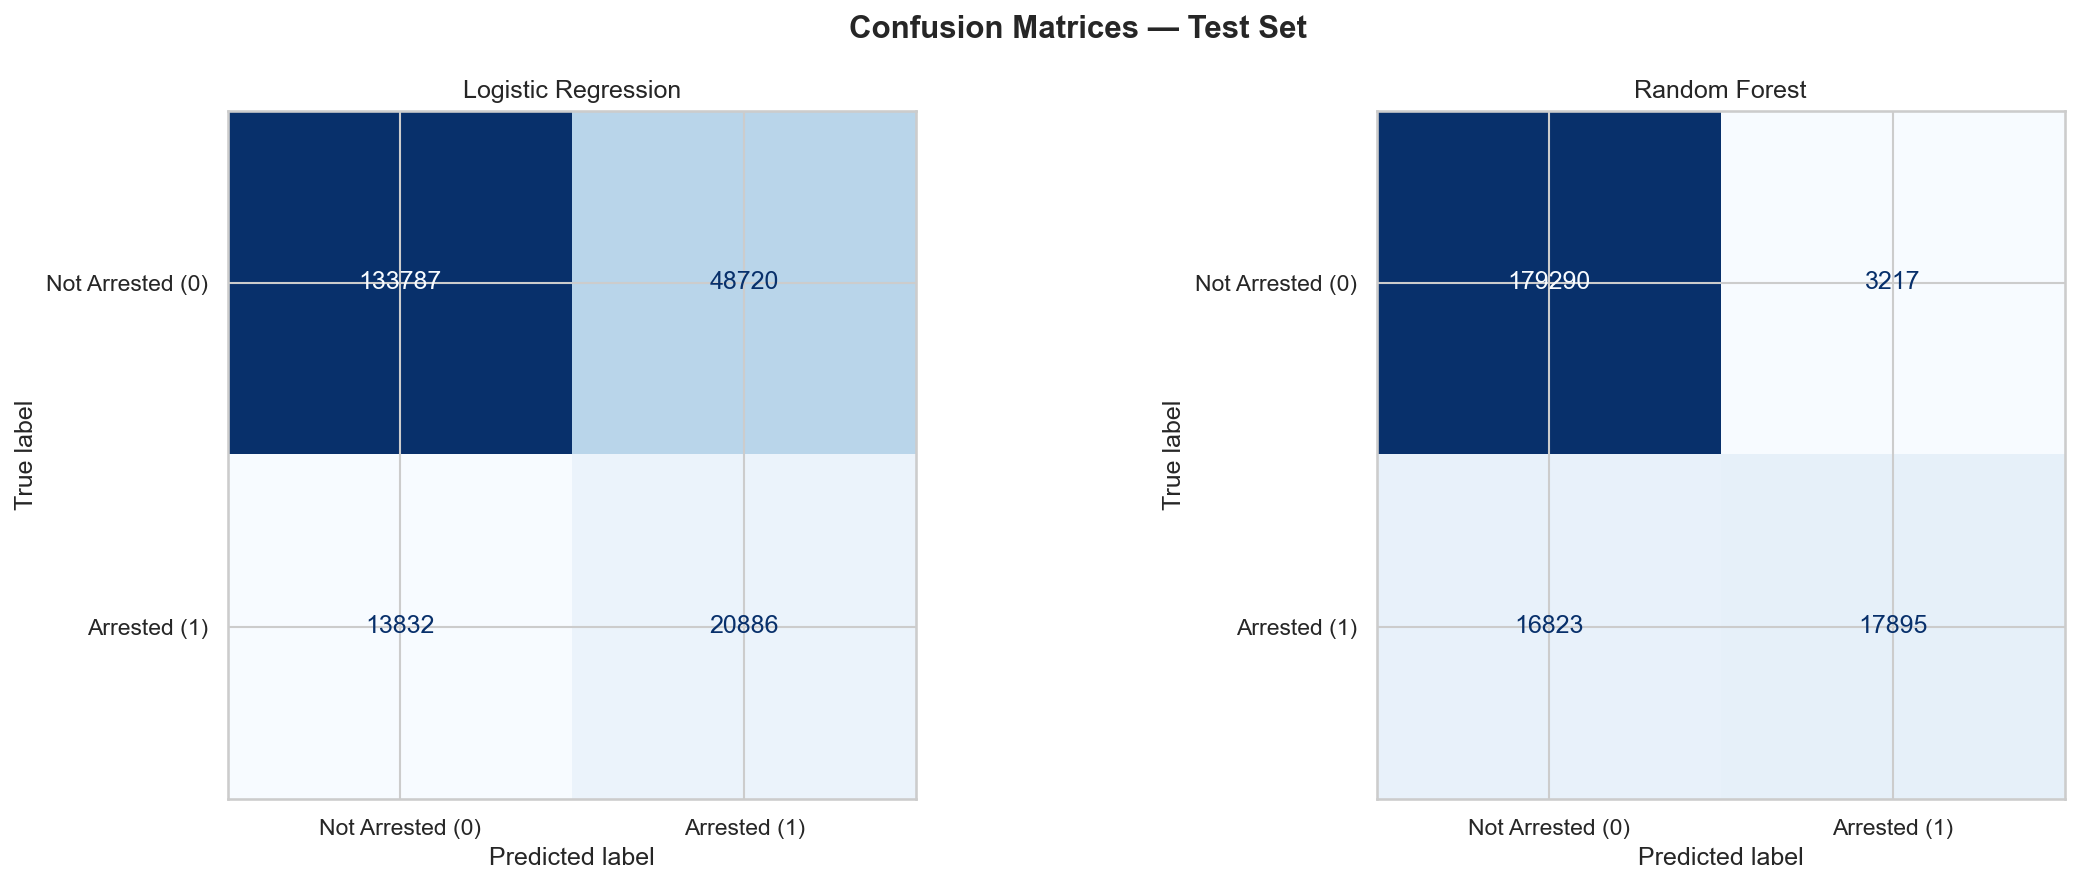

In [49]:
# Confusion matrices side by side 
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Confusion Matrices — Test Set', fontsize=15, fontweight='bold')

for ax, preds, name in zip(axes, [lr_preds, rf_preds],
                            ['Logistic Regression', 'Random Forest']):
    ConfusionMatrixDisplay.from_predictions(
        y_test, preds,
        display_labels=['Not Arrested (0)', 'Arrested (1)'],
        cmap='Blues', ax=ax, colorbar=False
    )
    ax.set_title(name)

plt.tight_layout()
plt.show()

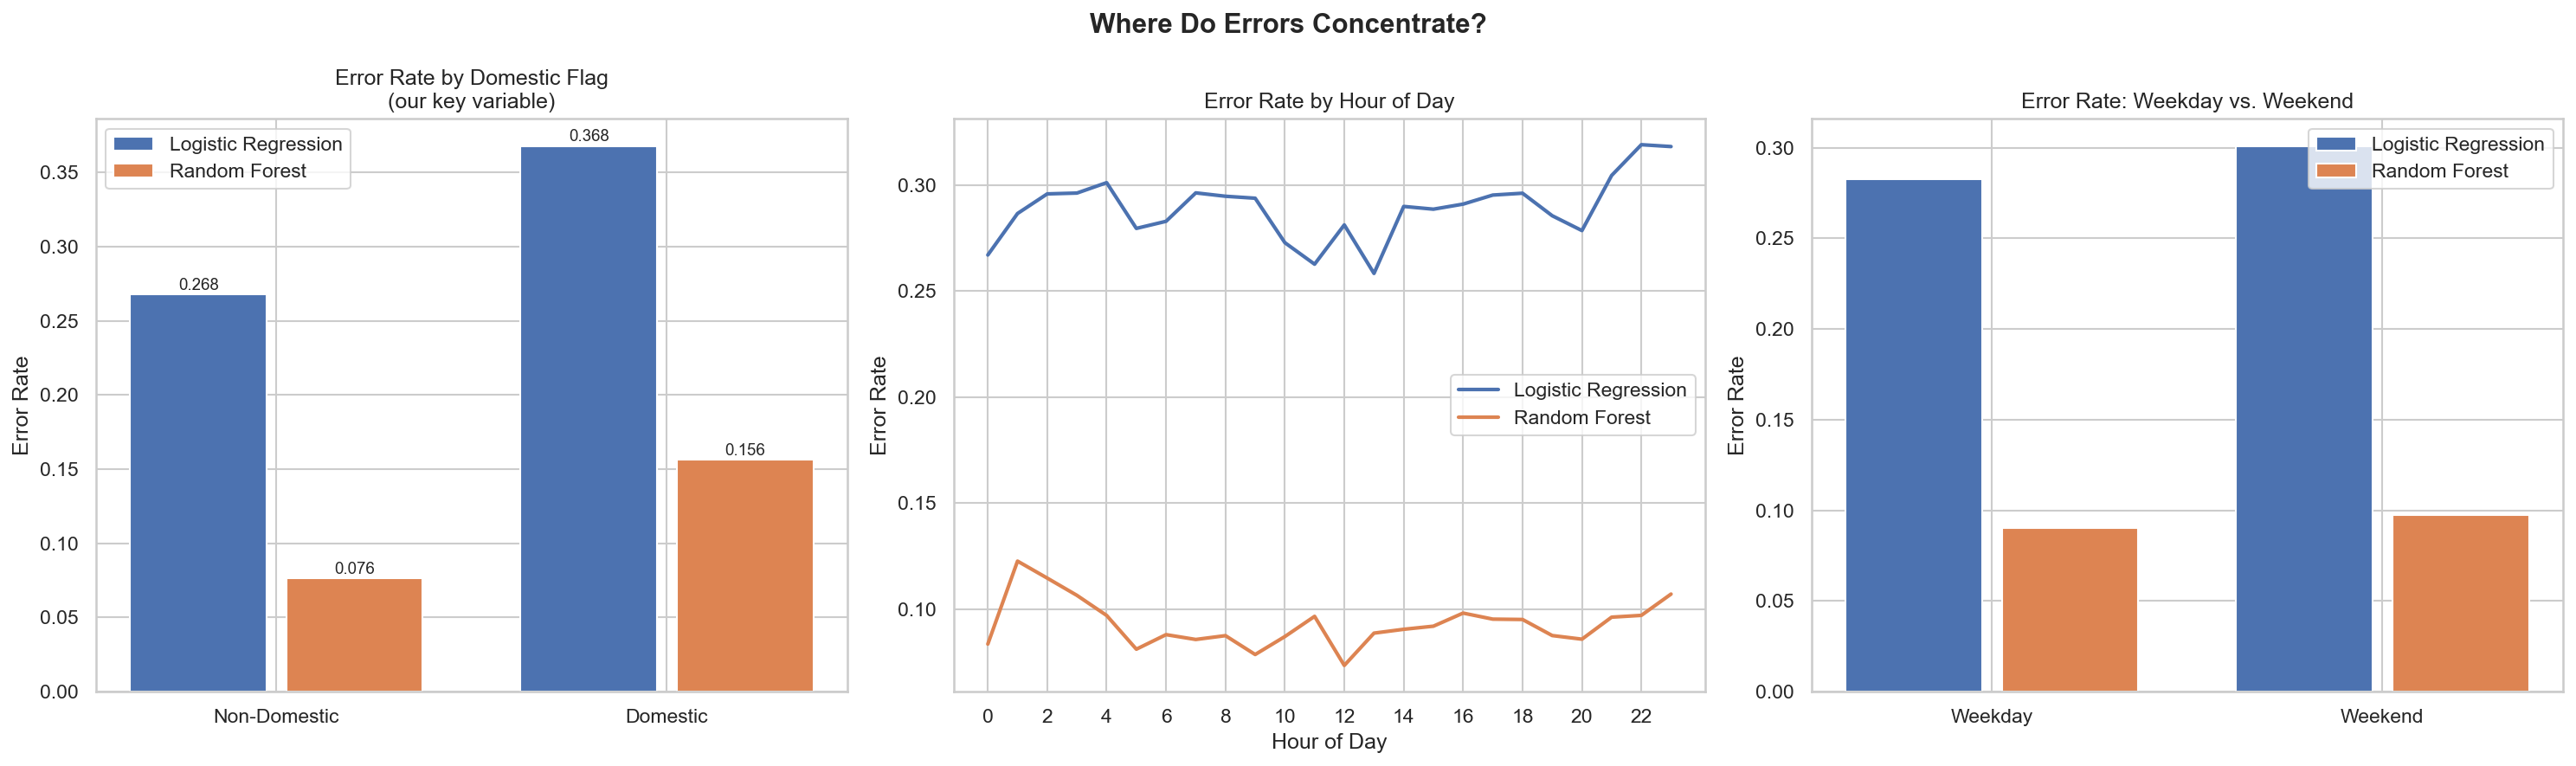

In [50]:
# -------------------------------------------------------
# WHERE DO ERRORS CONCENTRATE?
# -------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Where Do Errors Concentrate?', fontsize=15, fontweight='bold')

# Error rate by domestic flag
lr_err_by_dom = test_df.groupby('domestic')['lr_correct'].apply(lambda x: 1 - x.mean())
rf_err_by_dom = test_df.groupby('domestic')['rf_correct'].apply(lambda x: 1 - x.mean())
x = np.arange(2)
axes[0].bar(x - 0.2, lr_err_by_dom.values, width=0.35, label='Logistic Regression', color='#4C72B0')
axes[0].bar(x + 0.2, rf_err_by_dom.values, width=0.35, label='Random Forest', color='#DD8452')
axes[0].set_xticks(x)
axes[0].set_xticklabels(['Non-Domestic', 'Domestic'])
axes[0].set_ylabel('Error Rate')
axes[0].set_title('Error Rate by Domestic Flag\n(our key variable)')
axes[0].legend()
for i, (lr_v, rf_v) in enumerate(zip(lr_err_by_dom.values, rf_err_by_dom.values)):
    axes[0].text(i-0.2, lr_v+0.003, f'{lr_v:.3f}', ha='center', fontsize=9)
    axes[0].text(i+0.2, rf_v+0.003, f'{rf_v:.3f}', ha='center', fontsize=9)

# Error rate by hour
lr_err_hour = test_df.groupby('hour')['lr_correct'].apply(lambda x: 1-x.mean())
rf_err_hour = test_df.groupby('hour')['rf_correct'].apply(lambda x: 1-x.mean())
axes[1].plot(lr_err_hour.index, lr_err_hour.values, label='Logistic Regression', color='#4C72B0', linewidth=2)
axes[1].plot(rf_err_hour.index, rf_err_hour.values, label='Random Forest', color='#DD8452', linewidth=2)
axes[1].set_xlabel('Hour of Day')
axes[1].set_ylabel('Error Rate')
axes[1].set_title('Error Rate by Hour of Day')
axes[1].set_xticks(range(0, 24, 2))
axes[1].legend()

# Error rate by weekend
lr_err_wk = test_df.groupby('is_weekend')['lr_correct'].apply(lambda x: 1-x.mean())
rf_err_wk = test_df.groupby('is_weekend')['rf_correct'].apply(lambda x: 1-x.mean())
axes[2].bar(x - 0.2, lr_err_wk.values, width=0.35, label='Logistic Regression', color='#4C72B0')
axes[2].bar(x + 0.2, rf_err_wk.values, width=0.35, label='Random Forest', color='#DD8452')
axes[2].set_xticks(x)
axes[2].set_xticklabels(['Weekday', 'Weekend'])
axes[2].set_ylabel('Error Rate')
axes[2].set_title('Error Rate: Weekday vs. Weekend')
axes[2].legend()

plt.tight_layout()
plt.show()



In [51]:
# SPECIFIC ERROR EXAMPLES 
print('FALSE NEGATIVES — Domestic crimes where BOTH models missed the arrest')
print('(predicted Not Arrested, but arrest DID occur)')
print('='*65)

both_fn_domestic = test_df[
    (test_df['true_label'] == 1) &
    (test_df['lr_pred']    == 0) &
    (test_df['rf_pred']    == 0) &
    (test_df['domestic']   == 1)
]
print(f'Count: {len(both_fn_domestic):,}')
display(both_fn_domestic.head(10))

print('\nFALSE POSITIVES — Domestic crimes where BOTH models predicted arrest incorrectly')
print('(predicted Arrested, but arrest did NOT occur)')
print('='*65)

both_fp_domestic = test_df[
    (test_df['true_label'] == 0) &
    (test_df['lr_pred']    == 1) &
    (test_df['rf_pred']    == 1) &
    (test_df['domestic']   == 1)
]
print(f'Count: {len(both_fp_domestic):,}')
display(both_fp_domestic.head(10))

FALSE NEGATIVES — Domestic crimes where BOTH models missed the arrest
(predicted Not Arrested, but arrest DID occur)
Count: 4,867


,hour,day_of_week,month,season_encoded,is_weekend,community_area,district,location_description_encoded,primary_type_encoded,domestic,fbi_code_encoded,iucr_encoded,year,true_label,lr_pred,rf_pred,lr_correct,rf_correct,lr_error_type,rf_error_type
959423,8,0,11,0,0,71,6,1,2,1,10,8,2019,1,0,0,0,0,False Negative,False Negative
710647,19,0,1,3,0,25,15,1,2,1,10,8,2021,1,0,0,0,0,False Negative,False Negative
57151,17,3,10,0,0,25,11,35,1,1,9,14,2023,1,0,0,0,0,False Negative,False Negative
27481,22,1,11,0,0,46,4,32,2,1,10,8,2023,1,0,0,0,0,False Negative,False Negative
118321,18,0,7,2,0,71,6,1,2,1,10,8,2023,1,0,0,0,0,False Negative,False Negative
885505,16,1,3,1,0,24,14,1,2,1,10,8,2020,1,0,0,0,0,False Negative,False Negative
191980,22,5,4,1,1,21,17,1,2,1,10,8,2023,1,0,0,0,0,False Negative,False Negative
939802,12,1,12,3,0,43,3,1,1,1,9,14,2019,1,0,0,0,0,False Negative,False Negative
1118066,19,0,4,1,0,31,12,1,2,1,10,8,2019,1,0,0,0,0,False Negative,False Negative
593468,2,2,8,2,0,27,11,1,2,1,10,8,2021,1,0,0,0,0,False Negative,False Negative



FALSE POSITIVES — Domestic crimes where BOTH models predicted arrest incorrectly
(predicted Arrested, but arrest did NOT occur)
Count: 118


,hour,day_of_week,month,season_encoded,is_weekend,community_area,district,location_description_encoded,primary_type_encoded,domestic,fbi_code_encoded,iucr_encoded,year,true_label,lr_pred,rf_pred,lr_correct,rf_correct,lr_error_type,rf_error_type
1091454,10,2,5,1,0,66,8,32,23,1,25,47,2019,0,1,1,0,0,False Positive,False Positive
1423675,3,2,2,3,0,29,10,36,6,1,16,31,2018,0,1,1,0,0,False Positive,False Positive
1193189,19,5,12,3,1,61,9,32,23,1,25,47,2018,0,1,1,0,0,False Positive,False Positive
109189,0,5,8,2,1,35,2,1,2,1,10,50,2023,0,1,1,0,0,False Positive,False Positive
1036119,18,1,7,2,0,25,15,1,23,1,25,47,2019,0,1,1,0,0,False Positive,False Positive
902060,21,2,2,3,0,57,8,46,23,1,25,47,2020,0,1,1,0,0,False Positive,False Positive
1136003,21,2,3,1,0,48,4,46,23,1,25,47,2019,0,1,1,0,0,False Positive,False Positive
730580,20,5,11,0,1,29,10,1,2,1,10,50,2020,0,1,1,0,0,False Positive,False Positive
1112705,16,1,4,1,0,26,11,32,23,1,25,47,2019,0,1,1,0,0,False Positive,False Positive
1152036,23,5,2,3,1,49,5,32,2,1,10,8,2019,0,1,1,0,0,False Positive,False Positive


#### MODEL AGREEMENT: do they fail on the same cases?

'Both wrong' cases = 14,041 — neither model can predict these correctly.
  These likely represent cases where arrest was driven by factors
  not in our dataset (officer discretion, victim cooperation, prior record).

  'Only LR wrong' = 48,511 — non-linear patterns RF captures but LR misses.
  'Only RF wrong' = 5,999 — cases where LR's simpler model generalizes better.


MODEL AGREEMENT ANALYSIS
  Both correct:    148,674  (68.4%)
  Both wrong:       14,041  (6.5%)
  Only LR wrong:    48,511  (22.3%)
  Only RF wrong:     5,999  (2.8%)


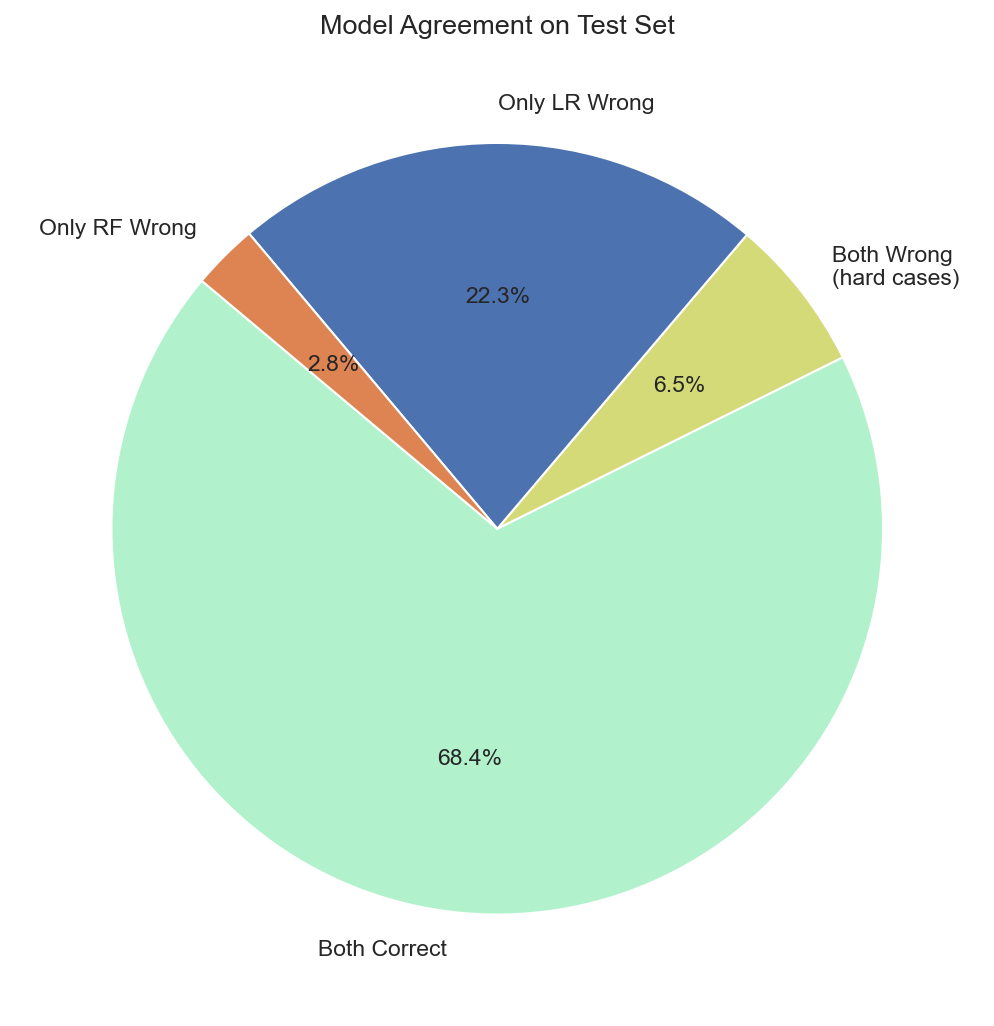

In [ ]:
# MODEL AGREEMENT — do they fail on the same cases?
both_correct  = ((test_df['lr_correct']==1) & (test_df['rf_correct']==1)).sum()
both_wrong    = ((test_df['lr_correct']==0) & (test_df['rf_correct']==0)).sum()
only_lr_wrong = ((test_df['lr_correct']==0) & (test_df['rf_correct']==1)).sum()
only_rf_wrong = ((test_df['lr_correct']==1) & (test_df['rf_correct']==0)).sum()
total = len(test_df)

print('\nMODEL AGREEMENT ANALYSIS')
print('='*55)
print(f'  Both correct:   {both_correct:>8,}  ({both_correct/total*100:.1f}%)')
print(f'  Both wrong:     {both_wrong:>8,}  ({both_wrong/total*100:.1f}%)')
print(f'  Only LR wrong:  {only_lr_wrong:>8,}  ({only_lr_wrong/total*100:.1f}%)')
print(f'  Only RF wrong:  {only_rf_wrong:>8,}  ({only_rf_wrong/total*100:.1f}%)')

fig, ax = plt.subplots(figsize=(7, 7))
sizes  = [both_correct, both_wrong, only_lr_wrong, only_rf_wrong]
labels = ['Both Correct', 'Both Wrong\n(hard cases)', 'Only LR Wrong', 'Only RF Wrong']
colors = ["#b1f2ccff", "#d5da78", '#4C72B0', '#DD8452']
ax.pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%',
       startangle=140, textprops={'fontsize': 11})
ax.set_title('Model Agreement on Test Set', fontsize=13)
plt.tight_layout()
plt.show()

# Conclusion: What does this mean?

1. Domestic flag matters independently: Both models agree: 'domestic' has a positive effect on arrest probability. Illinois mandatory arrest law (when probable cause exists in DV) drives higher domestic arrest rates.
2. Location matters more than domestic status: community_area and district rank above 'domestic' in both models. WHERE a crime occurs shapes policing response more than whether it is domestic. Directly supports Social Disorganization Theory.
3. Crime type is the strongest predictor: fbi_code, iucr, and primary_type dominate feature importance in both models. The type and severity of the crime matters most, domestic status is secondary but still significant.
4. Domestic outcomes are harder to predict: Both models show higher error rates on domestic crimes. Arrest decisions for domestic incidents are more discretionary and inconsistent, even controlling for crime type, location, and time.



